In [23]:
import os
import collections

import matplotlib.pyplot as plt
import seaborn as sns
import copy

import numpy as np
import pandas as pd
import itertools

from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import normalized_mutual_info_score
import statsmodels.api as sm


from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, VPacker, TextArea, DrawingArea
from matplotlib.lines import Line2D
import matplotlib as mpl


import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

sys.path.insert(1, '/home/hmbaghda/Projects/scLEMBAS/notebooks/') 
from notebook_utils import get_split, load_test_tfadata, clear_adata

In [24]:
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
fig_path = os.path.join(data_path, 'figures', 'presenting')
seed = 888
n_folds = 5

# McCauley

In [25]:
author = 'McCauley'
cat_col = 'cell_type'
pert_col = 'ligand'
ctrl_pert = 'CTRL'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))

In [ ]:
fn = os.path.join(data_path, 'processed', '{}_pruning_res_all.pickle'.format(author))
all_results = io.read_pickled_object(fn)

learned_weights = all_results["learned_weights"]
train_stats_df = all_results["train_stats_df"]
eval_stats_df = all_results["eval_stats_df"]
lr_stochastic = all_results["lr_stochastic"]

learned_weights.edge_type = pd.Categorical(learned_weights.edge_type, 
                                          categories = ['real', 'random'], 
                                           ordered = True
                                          )

    
learned_weights.edge_type = pd.Categorical(learned_weights.edge_type, 
                                          categories = ['real', 'random'], 
                                           ordered = True
                                          )


# -------------------- SETUP --------------------
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), constrained_layout=True)

stoch_color = sns.color_palette('Set1')[4]
real_color = sns.color_palette('Set1')[1]

real_mask = (learned_weights.edge_type == 'real')

# toggle whether to actually draw the spurious CDF
plot_spurious_line = False

# -------------------- CDF PANEL --------------------
j = 0

# # CDF visualization: per-model
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)
#     for ensemble_idx in range(5):
#         ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)
#
#         x_stoch, y_stoch = compute_cdf(
#             learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values,
#             log_transform=log_cdf_visual
#         )
#         x_real, y_real = compute_cdf(
#             learned_weights[real_mask & fold_mask & ensemble_mask].weights.values,
#             log_transform=log_cdf_visual
#         )
#
#         ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#         if plot_spurious_line:
#             ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# # CDF visualization: per-fold
# for fold in range(5):
#     fold_mask = (learned_weights.fold == fold)
#
#     x_stoch, y_stoch = compute_cdf(
#         learned_weights[fold_mask & ~real_mask].weights.values,
#         log_transform=log_cdf_visual
#     )
#     x_real, y_real = compute_cdf(
#         learned_weights[fold_mask & real_mask].weights.values,
#         log_transform=log_cdf_visual
#     )
#
#     ax[j].plot(x_real, y_real, color=real_color, alpha=0.3, linewidth=1, zorder=1)
#     if plot_spurious_line:
#         ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.3, linewidth=1, zorder=1)

# CDF visualization: all
x_stoch, y_stoch = compute_cdf(
    learned_weights[~real_mask].weights.values,
    log_transform=log_cdf_visual
)
x_real, y_real = compute_cdf(
    learned_weights[real_mask].weights.values,
    log_transform=log_cdf_visual
)

ax[j].plot(
    x_real, y_real,
    color=real_color, alpha=0.8, linewidth=3, zorder=2, label="Real"
)

if plot_spurious_line:
    ax[j].plot(
        x_stoch, y_stoch,
        color=stoch_color, alpha=0.8, linewidth=3, zorder=2, label="Spurious"
    )

# zoom in on relevant regime
# ax[j].set_ylim(0.9, 1.01)
# ax[j].set_xlim(-3.2, 3)

if weights_percentile_min is not None and weights_percentile_min > 0:
    weight_vals = np.log(learned_weights.weights) if log_cdf_visual else learned_weights.weights
    percentile_val = weight_vals.quantile(weights_percentile_min)

    _, xmax = ax[j].get_xlim()
    _, ymax = ax[j].get_ylim()

    xmin = percentile_val

    x_sorted, y_filtered = compute_cdf(
        learned_weights.weights.values,
        log_transform=log_cdf_visual
    )
    ymin = y_filtered[np.searchsorted(x_sorted, percentile_val, side='left')] * ymin_scaler

    ax[j].set_ylim(ymin, ymax * 0.975)
    ax[j].set_xlim(xmin, xmax * 0.975)

xlabel = "Learned Weight Magnitude" if not log_cdf_visual else "log(Learned Weight Magnitude)"
ax[j].set_xlabel(xlabel)
ax[j].set_ylabel("CDF")
ax[j].set_title("CDF of Weights Across Folds")
ax[j].set_yscale('log')

# manual legend so size/position stay consistent even when spurious line is hidden
handles = [
    plt.Line2D([0], [0], color=real_color, linewidth=3, label="Real"),
    plt.Line2D([0], [0], color=stoch_color, linewidth=3, label="Spurious")
]
ax[j].legend(
    handles=handles,
    loc='best'
)

# -------------------- BOXPLOT PANEL --------------------
j = 1

residuals_stochastic = []
residuals_real = []

for fold in range(5):
    fold_mask = (learned_weights.fold == fold)
    for ensemble_idx in range(5):
        ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)

        x_stoch, y_stoch = compute_cdf(
            learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values,
            log_transform=False
        )
        x_real, y_real = compute_cdf(
            learned_weights[real_mask & fold_mask & ensemble_mask].weights.values,
            log_transform=False
        )

        area_stoc = np.trapz(1 - y_stoch, x_stoch)
        area_real = np.trapz(1 - y_real, x_real)

        residuals_stochastic.append(area_stoc)
        residuals_real.append(area_real)

# same if run on normalized or not
a = np.array(residuals_real)
b = np.array(residuals_stochastic)
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b, alternative='greater').pvalue

mean_real = np.mean(residuals_real)

df_box = pd.DataFrame({
    "value": np.concatenate([
        np.array(residuals_real) / mean_real,
        np.array(residuals_stochastic) / mean_real,
    ]),
    "type": ["Real"] * len(residuals_real) + ["Spurious"] * len(residuals_stochastic)
})

sns.boxplot(
    data=df_box,
    x="type",
    y="value",
    palette={"Spurious": stoch_color, "Real": real_color},
    ax=ax[j]
)

ax[j].set_ylabel("Relative Residual Area of (1 - CDF)")
ax[j].set_xlabel("")
ax[j].set_title("Boxplot of Residual Areas Across Folds")

annot_text = f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}"
ax[j].text(
    0.02, 0.02, annot_text,
    transform=ax[j].transAxes,
    ha='left',
    va='bottom',
    fontsize=11,
)

for ext in ['png']:
    fig.savefig(
        os.path.join(data_path, 'figures', 'presenting', '{}_self_pruning_cdf_nospurious.{}'.format(author, ext)),
        dpi=1200 if ext == "png" else None,
        bbox_inches="tight",
        transparent=True
    )

plt.show()



# -------------------- SETUP --------------------
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), constrained_layout=True)

stoch_color = sns.color_palette('Set1')[4]
real_color = sns.color_palette('Set1')[1]

real_mask = (learned_weights.edge_type == 'real')

# -------------------- CDF PANEL --------------------
j = 0

# CDF visualization: all
x_stoch, y_stoch = compute_cdf(
    learned_weights[~real_mask].weights.values,
    log_transform=log_cdf_visual
)
x_real, y_real = compute_cdf(
    learned_weights[real_mask].weights.values,
    log_transform=log_cdf_visual
)

# --- shared x-grid for shading ---
x_common = np.unique(np.concatenate([x_real, x_stoch]))
y_real_interp = np.interp(x_common, x_real, y_real)
y_stoch_interp = np.interp(x_common, x_stoch, y_stoch)

# --- shaded region ---
ax[j].fill_between(
    x_common,
    y_real_interp,
    y_stoch_interp,
    color="gray",
    alpha=0.4,
    zorder=1
)

# --- lines on top ---
ax[j].plot(
    x_real, y_real,
    color=real_color, alpha=0.8, linewidth=3, zorder=3, label="Real"
)
ax[j].plot(
    x_stoch, y_stoch,
    color=stoch_color, alpha=0.8, linewidth=3, zorder=3, label="Spurious"
)

# zoom in on relevant regime
# ax[j].set_ylim(0.9, 1.01)
# ax[j].set_xlim(-3.2, 3)

if weights_percentile_min is not None and weights_percentile_min > 0:
    weight_vals = np.log(learned_weights.weights) if log_cdf_visual else learned_weights.weights
    percentile_val = weight_vals.quantile(weights_percentile_min)

    _, xmax = ax[j].get_xlim()
    _, ymax = ax[j].get_ylim()

    xmin = percentile_val

    x_sorted, y_filtered = compute_cdf(
        learned_weights.weights.values,
        log_transform=log_cdf_visual
    )
    ymin = y_filtered[np.searchsorted(x_sorted, percentile_val, side='left')] * ymin_scaler

    ax[j].set_ylim(ymin, ymax * 0.975)
    ax[j].set_xlim(xmin, xmax * 0.975)

xlabel = "Learned Weight Magnitude" if not log_cdf_visual else "log(Learned Weight Magnitude)"
ax[j].set_xlabel(xlabel)
ax[j].set_ylabel("CDF")
ax[j].set_title("CDF of Weights Across Folds")
ax[j].set_yscale('log')

# consistent legend (manual)
handles = [
    plt.Line2D([0], [0], color=real_color, linewidth=3, label="Real"),
    plt.Line2D([0], [0], color=stoch_color, linewidth=3, label="Spurious")
]
ax[j].legend(handles=handles, loc='best')

# -------------------- BOXPLOT PANEL --------------------
j = 1

residuals_stochastic = []
residuals_real = []

# residual statistics
for fold in range(5):
    fold_mask = (learned_weights.fold == fold)
    for ensemble_idx in range(5):
        ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)

        x_stoch, y_stoch = compute_cdf(
            learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values,
            log_transform=False
        )
        x_real, y_real = compute_cdf(
            learned_weights[real_mask & fold_mask & ensemble_mask].weights.values,
            log_transform=False
        )

        area_stoc = np.trapz(1 - y_stoch, x_stoch)
        area_real = np.trapz(1 - y_real, x_real)

        residuals_stochastic.append(area_stoc)
        residuals_real.append(area_real)

# stats
a = np.array(residuals_real)
b = np.array(residuals_stochastic)
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b, alternative='greater').pvalue

mean_real = np.mean(residuals_real)

df_box = pd.DataFrame({
    "value": np.concatenate([
        np.array(residuals_real) / mean_real,
        np.array(residuals_stochastic) / mean_real,
    ]),
    "type": ["Real"] * len(residuals_real) +
            ["Spurious"] * len(residuals_stochastic)
})

sns.boxplot(
    data=df_box,
    x="type",
    y="value",
    palette={"Spurious": stoch_color, "Real": real_color},
    ax=ax[j]
)

ax[j].set_ylabel("Relative Residual Area of (1 - CDF)")
ax[j].set_xlabel("")
ax[j].set_title("Boxplot of Residual Areas Across Folds")

annot_text = f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}"
ax[j].text(
    0.02, 0.02, annot_text,
    transform=ax[j].transAxes,
    ha='left',
    va='bottom',
    fontsize=11,
)

# -------------------- SAVE --------------------
for ext in ['png']:
    fig.savefig(
        os.path.join(data_path, 'figures','presenting', '{}_self_pruning_cdf_shaded.{}'.format(author, ext)),
        dpi=1200 if ext == "png" else None,
        bbox_inches="tight",
        transparent=True
    )

plt.show()


# -------------------- SETUP --------------------
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), constrained_layout=True)

stoch_color = sns.color_palette('Set1')[4]
real_color = sns.color_palette('Set1')[1]

real_mask = (learned_weights.edge_type == 'real')

# -------------------- CDF PANEL --------------------
j = 0

# CDF visualization: all
x_stoch, y_stoch = compute_cdf(learned_weights[~real_mask].weights.values, log_transform = log_cdf_visual)
x_real, y_real = compute_cdf(learned_weights[real_mask].weights.values, log_transform = log_cdf_visual)
ax[j].plot(x_real, y_real, color=real_color, alpha=0.8, linewidth=3, zorder=2, label="Real")
ax[j].plot(x_stoch, y_stoch, color=stoch_color, alpha=0.8, linewidth=3, zorder=2, label="Spurious")

# zoom in on relevant regime
# ax[j].set_ylim(0.9, 1.01)
# ax[j].set_xlim(-3.2, 3)

if weights_percentile_min is not None and weights_percentile_min > 0:
    weight_vals = np.log(learned_weights.weights) if log_cdf_visual else learned_weights.weights
    percentile_val = weight_vals.quantile(weights_percentile_min)
    
    _, xmax = ax[j].get_xlim()
    _, ymax = ax[j].get_ylim()
    
    xmin = percentile_val
    
    x_sorted, y_filtered = compute_cdf(learned_weights.weights.values,log_transform=log_cdf_visual)
    ymin = y_filtered[np.searchsorted(x_sorted, percentile_val, side='left')] * ymin_scaler
    
    ax[j].set_ylim(ymin, ymax*0.975)
    ax[j].set_xlim(xmin, xmax*0.975)


xlabel = "Learned Weight Magnitude" if not log_cdf_visual else "log(Learned Weight Magnitude)"
ax[j].set_xlabel(xlabel)
ax[j].set_ylabel("CDF")
ax[j].set_title("CDF of Weights Across Folds")
ax[j].set_yscale('log')

# clean legend (ONLY CHANGE: linewidth=3)
handles = [
    plt.Line2D([0], [0], color=real_color, linewidth=3, label="Real"),
    plt.Line2D([0], [0], color=stoch_color, linewidth=3, label="Spurious")
]
ax[j].legend(handles=handles)


# -------------------- BOXPLOT PANEL --------------------
j = 1

residuals_stochastic = []
residuals_real = []

for fold in range(5):
    fold_mask = (learned_weights.fold == fold)
    for ensemble_idx in range(5):
        ensemble_mask = (learned_weights.ensemble_idx == ensemble_idx)
        
        x_stoch, y_stoch = compute_cdf(
            learned_weights[~real_mask & fold_mask & ensemble_mask].weights.values, log_transform = False
        )
        x_real, y_real = compute_cdf(
            learned_weights[real_mask & fold_mask & ensemble_mask].weights.values, log_transform = False
        )
        
        area_stoc = np.trapz(1 - y_stoch, x_stoch)
        area_real = np.trapz(1 - y_real, x_real)

        residuals_stochastic.append(area_stoc)
        residuals_real.append(area_real)
        
a = np.array(residuals_real)
b = np.array(residuals_stochastic)
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b, alternative = 'greater').pvalue

mean_real = np.mean(residuals_real)

df_box = pd.DataFrame({
    "value": np.concatenate([
        np.array(residuals_real) / mean_real, 
        np.array(residuals_stochastic) / mean_real,
    ]),
    "type": ["Real"] * len(residuals_real) + 
    ["Spurious"] * len(residuals_stochastic)
})

sns.boxplot(
    data=df_box,
    x="type",
    y="value",
    palette={"Spurious": stoch_color, "Real": real_color},
    ax=ax[j]
)

ax[j].set_ylabel("Relative Residual Area of (1 - CDF)")
ax[j].set_xlabel("")
ax[j].set_title("Boxplot of Residual Areas Across Folds")

annot_text = f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}"
ax[j].text(
    0.02, 0.02, annot_text,
    transform=ax[j].transAxes,
    ha='left',
    va='bottom',
    fontsize=11,
)

for ext in ['png']:
    fig.savefig(
        os.path.join(data_path, 'figures','presenting', '{}_self_pruning_cdf.{}'.format(author, ext)),
        dpi=1200 if ext == "png" else None,
        bbox_inches="tight",
        transparent=True
    )

plt.show()

In [26]:
sns.set_context(
    "talk",
    font_scale=1.2,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

''

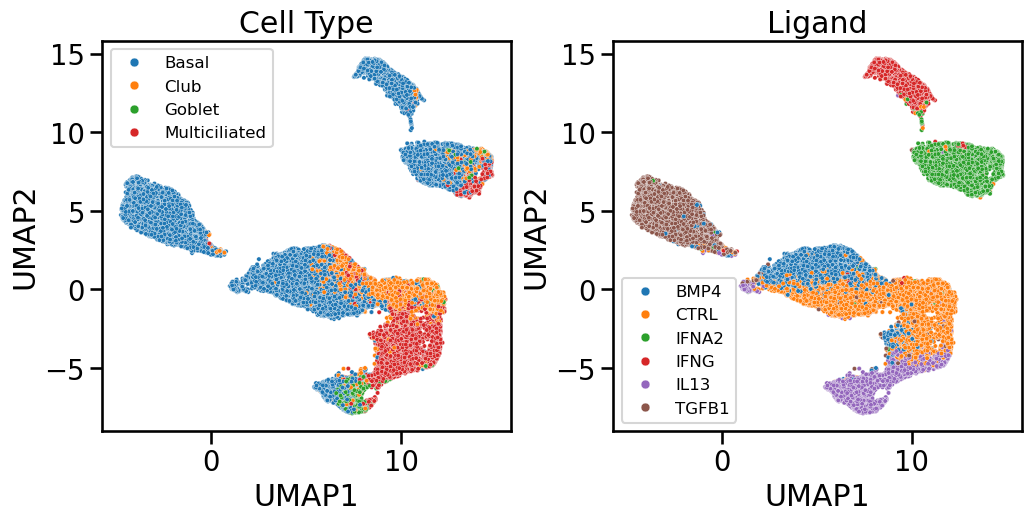

In [5]:
ncols, nrows = 2,1
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(5.1*ncols, 5.1*nrows), constrained_layout = True)
ax = np.array(axes).reshape(nrows, ncols)
# ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# ax = ax.flatten()
plot_type = 'scatter'

ll_map = {'umap': 'PCA-Derived UMAP', 
         'umap_pls': ''} #'PLS-Derived UMAP'}

for i, latent_label in enumerate(['umap_pls']):
    viz_df = pd.DataFrame(tf_adata.obsm['X_' + latent_label])
    _label_name = 'UMAP'
    viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
    for covariate in [cat_col, pert_col]:
        viz_df[covariate] = tf_adata.obs[covariate].reset_index(drop=True)
    
    viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    
    for (j, covariate) in enumerate([cat_col, pert_col]):
        if plot_type == 'scatter':
            sns.scatterplot(data = viz_df, 
                            x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                            ax = ax[i, j], s = 10)
        elif plot_type == 'contour':
            sns.kdeplot(data = viz_df, 
                        x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                        ax = ax[i, j], fill = False, levels = 5)
        
        
        if ax[i,j].legend_ is not None and i != 0:
            ax[i,j].legend_.remove()
        else:
            title = ax[i, j].get_legend().get_title().get_text()
            ax[i, j].legend(title=None, markerscale=2)#' '.join([c.capitalize() for c in title.split('_')]))
            
        ax[i,j].set_title('{}'.format(
            ' '.join([c.capitalize() for c in covariate.split('_')])))
            
#         ax[i,j].set_title('{} | {}'.format(
#             ' '.join([c.capitalize() for c in covariate.split('_')]), 
#             ll_map[latent_label]))

fig.savefig(os.path.join(fig_path, '{}_TF_filtered_umap_visualization.png'.format(author)), 
            dpi=1200, bbox_inches="tight")
;

In [6]:
merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

cspm = io.read_pickled_object(os.path.join(data_path, 'interim', '{}_test_condition_PLS_models.pickle'.format(author)))



In [45]:
n_folds = 5
ls_label_dict = {
    'pls': 'PLS', 
    'pca': 'PC'
}

In [46]:
def subsample_viz_df(viz_df, group_col, cats, frac=0.15, min_keep=50, exempt_cats=None):
    """
    Randomly subsample each group in viz_df, keeping at least min_keep points.
    Groups in exempt_cats are left untouched.
    """
    exempt_cats = exempt_cats or []
    parts = []
    for cat in cats:
        tmp = viz_df[viz_df[group_col] == cat]
        if cat in exempt_cats:
            parts.append(tmp)
        else:
            n_keep = max(min_keep, int(len(tmp) * frac))
            parts.append(tmp.sample(n=min(n_keep, len(tmp)), random_state=0))
    return pd.concat(parts)


def plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde = 75, is_last_col = False):

    adata_dict = {
        'Actual': tf_adata_actual,
        'Predicted': tf_adata_predicted
    }

    cats = None

    for (i, (adata_type, adata)) in enumerate(adata_dict.items()):

        viz_df = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
        viz_df.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df.shape[1])]

        viz_df[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()
        viz_df[group_col].apply
        cats = sorted(viz_df[group_col].unique())
        viz_df[group_col] = pd.Categorical(viz_df[group_col],
                                           categories = cats, ordered = True)

        # --- KDE for groups that can support it; scatter fallback for tiny / singular groups ---

        small_cats = []
        for cat in cats:
            tmp = viz_df[viz_df[group_col] == cat]

            # too few points
            if tmp.shape[0] < min_points_kde:
                small_cats.append(cat)
                continue

            # singular / near-singular geometry (no 2D contour possible)
            xvar = np.var(tmp['{}1'.format(ls_label_dict[ls])].values)
            yvar = np.var(tmp['{}2'.format(ls_label_dict[ls])].values)
            if (xvar <= 1e-12) or (yvar <= 1e-12):
                small_cats.append(cat)

        viz_df_kde = viz_df[~viz_df[group_col].isin(small_cats)]

        if viz_df_kde.shape[0] > 0:
            sns.kdeplot(data = viz_df_kde,
                        x = '{}1'.format(ls_label_dict[ls]),
                        y = '{}2'.format(ls_label_dict[ls]),
                        hue = group_col, fill = False, levels = 5,
                        warn_singular = False,
                        ax = ax[i])

        # scatter overlay for small / singular groups (so they never disappear)
        palette = sns.color_palette(n_colors = len(cats))
        color_map = {cat: color for (cat, color) in zip(cats, palette)}

        for cat in small_cats:
            tmp = viz_df[viz_df[group_col] == cat]
            ax[i].scatter(tmp['{}1'.format(ls_label_dict[ls])],
                          tmp['{}2'.format(ls_label_dict[ls])],
                          s = 9, alpha = 0.9,
                          color = color_map[cat])

        # titles: only top row
        if i == 0:
            ax[i].set_title('Fold: {}'.format(fold + 1))
        else:
            ax[i].set_title('')

        # clear seaborn auto-legend
        ax[i].legend_.remove() if ax[i].legend_ is not None else None

#         # right-side y-axis labels only on final column
#         if is_last_col:
#             ax_r = ax[i].twinx()                 
#             ax_r.set_ylabel(adata_type, labelpad = 20)
#             ax_r.set_yticks([])              
#             ax_r.tick_params(right=False)
#             ax_r.spines['right'].set_visible(False)
#         else:
#             ax[i].set_ylabel('')

#     # ensure same bounds (robust quantiles)
#     xmin, xmax, ymin, ymax = np.inf, -np.inf, np.inf, -np.inf

#     q_lo = 0.005
#     q_hi = 0.995

#     for (adata_type, adata) in adata_dict.items():
#         X = adata.obsm['X_{}'.format(ls)]

#         x_lo = np.quantile(X[:, 0], q_lo)
#         x_hi = np.quantile(X[:, 0], q_hi)
#         y_lo = np.quantile(X[:, 1], q_lo)
#         y_hi = np.quantile(X[:, 1], q_hi)

#         if x_lo < xmin:
#             xmin = x_lo
#         if x_hi > xmax:
#             xmax = x_hi
#         if y_lo < ymin:
#             ymin = y_lo
#         if y_hi > ymax:
#             ymax = y_hi

#     # small padding
#     pad = 0.15
#     dx = (xmax - xmin) * pad
#     dy = (ymax - ymin) * pad
#     xmin = xmin - dx
#     xmax = xmax + dx
#     ymin = ymin - dy
#     ymax = ymax + dy

#     for j in range(2):
#         ax[j].set_xlim(xmin, xmax)
#         ax[j].set_ylim(ymin, ymax)

    # legend (only once per column, on top axis)
    handles = []
    labels = []
    palette = sns.color_palette(n_colors = len(cats))
    for color, cat in zip(palette, cats):
        handles.append(Line2D([0], [0], color = color, lw = 2))
        labels.append(cat)
    ax[0].legend(handles = handles, labels = labels, title = '')

    return cats


def plot_fold_column_(tf_adata_actual, tf_adata_predicted,
                     ls, group_col, ax, min_points_kde=75, is_last_col=False):

    adata_dict = {
        'Actual': tf_adata_actual,
        'Predicted': tf_adata_predicted
    }

    cats = None

    for (i, (adata_type, adata)) in enumerate(adata_dict.items()):

        viz_df = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
        viz_df.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df.shape[1])]

        viz_df[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()
        cats = sorted(viz_df[group_col].unique())
        viz_df[group_col] = pd.Categorical(viz_df[group_col],
                                           categories=cats, ordered=True)

        # --- sparsify: subsample all groups except 'Goblet, IL13' in non-Predicted panels ---
        viz_df = subsample_viz_df(
            viz_df, group_col, cats,
            frac=0.15,
            min_keep=50,
            exempt_cats=['Goblet, IL13'] if adata_type == 'Predicted' else []
        )

        # --- KDE for groups that can support it; scatter fallback for tiny / singular groups ---
        small_cats = []
        for cat in cats:
            tmp = viz_df[viz_df[group_col] == cat]

            if tmp.shape[0] < min_points_kde:
                small_cats.append(cat)
                continue

            xvar = np.var(tmp['{}1'.format(ls_label_dict[ls])].values)
            yvar = np.var(tmp['{}2'.format(ls_label_dict[ls])].values)
            if (xvar <= 1e-12) or (yvar <= 1e-12):
                small_cats.append(cat)

        viz_df_kde = viz_df[~viz_df[group_col].isin(small_cats)]

        if viz_df_kde.shape[0] > 0:
            sns.kdeplot(data=viz_df_kde,
                        x='{}1'.format(ls_label_dict[ls]),
                        y='{}2'.format(ls_label_dict[ls]),
                        hue=group_col, fill=False, levels=5,
                        warn_singular=False,
                        ax=ax[i])

        palette = sns.color_palette(n_colors=len(cats))
        color_map = {cat: color for (cat, color) in zip(cats, palette)}

        for cat in small_cats:
            tmp = viz_df[viz_df[group_col] == cat]
            ax[i].scatter(tmp['{}1'.format(ls_label_dict[ls])],
                          tmp['{}2'.format(ls_label_dict[ls])],
                          s=9, alpha=0.9,
                          color=color_map[cat])

        if i == 0:
            ax[i].set_title('Fold: {}'.format(fold + 1))
        else:
            ax[i].set_title('')

        ax[i].legend_.remove() if ax[i].legend_ is not None else None

        if is_last_col:
            ax_r = ax[i].twinx()
            ax_r.set_ylabel(adata_type, labelpad=20)
            ax_r.set_yticks([])
            ax_r.tick_params(right=False)
            ax_r.spines['right'].set_visible(False)

    # legend
    handles = []
    labels = []
    palette = sns.color_palette(n_colors=len(cats))
    for color, cat in zip(palette, cats):
        handles.append(Line2D([0], [0], color=color, lw=2))
        labels.append(cat)
    ax[0].legend(handles=handles, labels=labels, title='')

    return cats



def clear_tfadata(tf_adata_actual, tf_adata_predicted):
    cols = [pert_col, cat_col, 'condition', 'batch', 'barcode']
    tf_adata_actual.obs = tf_adata_actual.obs[cols].copy()
    tf_adata_predicted.obs = tf_adata_predicted.obs[cols].copy()

    del tf_adata_actual.obsm['X_pls'], tf_adata_actual.obsm['X_umap_pls']
    del tf_adata_predicted.obsm['X_pls'], tf_adata_predicted.obsm['X_umap_pls']
    
    return tf_adata_actual, tf_adata_predicted


def test_condition_specific_pls_fits(tf_adata_actual, tf_adata_predicted, fold, baseline = False):
    """Refits PLS on the only the actual test conditions specifically separated by condition, 
    rather than on all data separated by perturbation """
    
    if not baseline:
        tf_adata_actual, tf_adata_predicted = clear_tfadata(tf_adata_actual, tf_adata_predicted)
    pls_model = cspm[fold]
    
    X_actual_pls = pls_model.transform(tf_adata_actual.X)
    tf_adata_actual.obsm['X_pls'] = X_actual_pls
    
    X_pred_pls = pls_model.transform(tf_adata_predicted.X)
    tf_adata_predicted.obsm['X_pls'] = X_pred_pls
    
    return tf_adata_actual, tf_adata_predicted

# redfine plotting with this additional step
def plot_fold_column(fold, ls, group_col, ax, min_points_kde = 75, is_last_col = False):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, author, merged_adatas, tf_adata)
    tf_adata_actual, tf_adata_predicted = test_condition_specific_pls_fits(tf_adata_actual, tf_adata_predicted, fold, baseline = False)
    cats = plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde, is_last_col)
    return cats


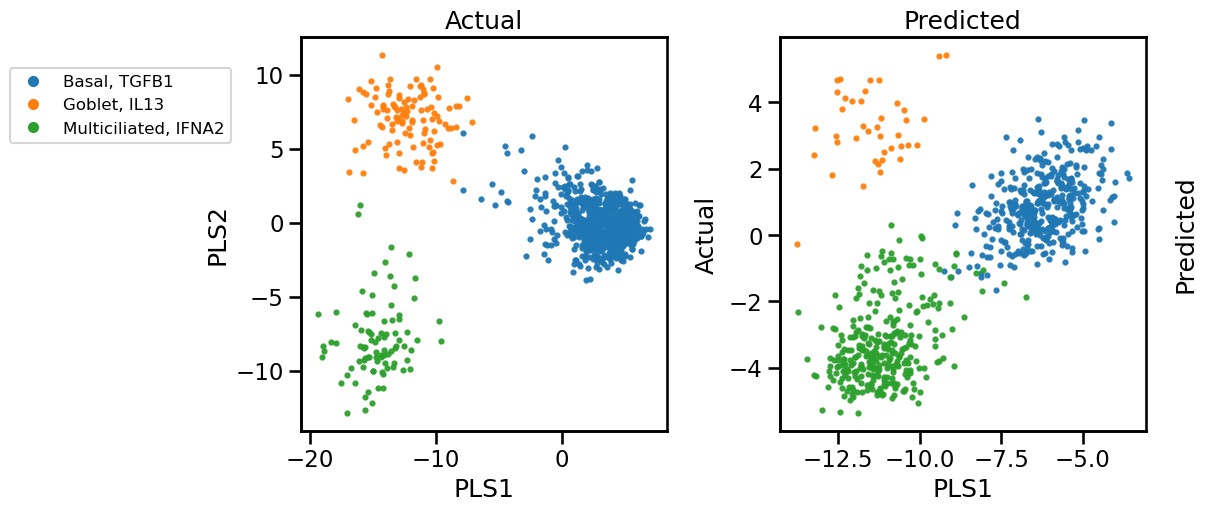

''

In [50]:
sns.set_context(
    "talk",
    font_scale=1,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

fig, ax = plt.subplots(
    nrows=1, ncols=2,
    figsize=(10, 5),
    constrained_layout=True
)

ax = np.array(ax).reshape(1, 2)

for fold in range(n_folds):
    if fold != 4:
        continue

    cats = plot_fold_column(          # <-- capture cats
        fold=fold,
        ls='pls',
        group_col='condition',
        ax=[ax[0, 0], ax[0, 1]],
        min_points_kde=1e6,
        is_last_col=True
    )

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        if j == 0:
            ax[i, j].set_ylabel('PLS2')
        else:
            ax[i, j].set_ylabel('')

        if i == ax.shape[0] - 1:
            ax[i, j].set_xlabel('PLS1')
        else:
            ax[i, j].set_xlabel('')

for j in range(2):
    ax[0, j].set_title('Actual' if j == 0 else 'Predicted')

# --- (1) grab legend from ax[0,0] and (2) swap line handles → scatter markers ---
src_legend = ax[0, 0].get_legend()
if src_legend is not None:
    labels = [t.get_text() for t in src_legend.get_texts()]
    orig_colors = [h.get_color() for h in src_legend.legend_handles]

    scatter_handles = [
        Line2D([0], [0],
               marker='o', color='none',
               markerfacecolor=c, markeredgecolor=c,
               markersize=7)
        for c in orig_colors
    ]

    # remove the panel legend
    src_legend.remove()

    # place as figure legend, outside left
    fig.legend(
        handles=scatter_handles,
        labels=labels,
        title='',
        loc='center left',
        bbox_to_anchor=(-0.2, 0.8),   # nudge left of the figure
    )


fig.savefig(
    os.path.join(fig_path, f'{author}_predictions_fold4.png'),
    dpi=1200,
    bbox_inches="tight"
)
plt.show()

;

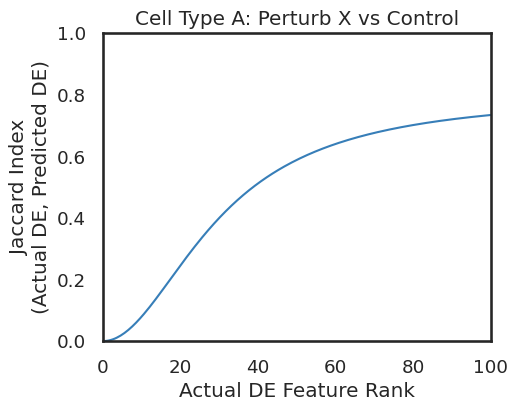

In [79]:
sns.set_context(
    "talk",
    font_scale=0.8,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)
sns.set_style('white')

# reproducibility
np.random.seed(42)

# x range
x = np.linspace(0, 100, 200)

# saturating "power-like" curve (Hill function)
K = 30     # half-saturation (controls where it bends)
n = 2      # steepness (higher = more switch-like)
y = 0.8 * (x**n / (x**n + K**n))

# add jitter
y_jitter = y + np.random.normal(0, 0.02, size=len(y))
y_jitter = np.clip(y_jitter, 0, 1)

# dataframe
df = pd.DataFrame({'x': x, 'y': y_jitter})

# plot
# sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(5, 4))

# sns.scatterplot(data=df, x='x', y='y', s=15, alpha=0.6, ax=ax)
sns.lineplot(x=x, y=y, color=sns.color_palette('Set1')[1], linewidth=1.5, ax=ax)

ax.set_xlim(0, 100)
ax.set_ylim(0, 1)

ax.set_xlabel("Actual DE Feature Rank")
ax.set_ylabel("Jaccard Index\n(Actual DE, Predicted DE)")
ax.set_title('Cell Type A: Perturb X vs Control')

fig.savefig(os.path.join(fig_path, 'CATplot_toy_example.png'.format(author)), 
            dpi=1200, bbox_inches="tight")

plt.show()

In [9]:
merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

cspm_ = io.read_pickled_object(os.path.join(data_path, 'interim', '{}_test_condition_PLS_models.pickle'.format(author)))

# format for input to emd loss function
cspm = {}
for fold in range(5):
    split = get_split(fold, author)
    test_conds = split['test_conds']
    for test_cond in test_conds:
        cspm[test_cond] = copy.deepcopy(cspm_[fold])
        

def load_test_tfadata(fold, key):
    key_ = '{}_{}'.format(key, fold)
    tf_adata_merged = merged_adatas[key_].copy()
        
    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[test_cond_mask,:].copy()
    assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'
    
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')
    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()    
    tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
    assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], 'Incorrect subsetting of actual data'

    return tf_adata_actual, tf_adata_predicted

In [36]:
remove_types = [
    'none',
    ['adj', 'categorical_bias'],
    ['adj', 'global_bias'],
    'total_bias', 
    'adj',
    'categorical_bias',
    'global_bias'
]
remove_types = [rt if type(rt) != list else '^'.join(rt) for rt in remove_types]

ablated_components = {
    'none': 'None', 
    'global_bias': 'Global Bias', 
    'adj^global_bias': 'Adj + Global Bias', 
    'total_bias': 'Total Bias',
    'adj^categorical_bias': 'Adj + Categorical Bias', 
    'adj': 'Adjaceny Matrix\nOnly', 
    'categorical_bias': 'Categorical Bias\nOnly', 
                       }
remaining_components = {'none': 'Full Model', 
                        'global_bias': 'Adj + Categorical Bias', 
                        'adj^global_bias': 'Categorical Bias Only',
                        'total_bias': 'Adjaceny Matrix Only',
                       'adj^categorical_bias': 'Global Bias Only', 
                       'adj': 'Total Bias', 
                       'categorical_bias': 'Adj + Global Bias', 
                       }

ar_c = {}
for k,v  in ablated_components.items():
    ar_c[k] =  '{}'.format(ablated_components[k]) #'\n({})'.format(ablated_components[k], remaining_components[k])
    
    
iterables = itertools.product(range(5), remove_types)
emd_loss = pd.read_csv(os.path.join(data_path, 'processed', '{}_emd_loss_per_component.csv'), index_col = 0)

emd_loss['Model Components'] = pd.Categorical(
    emd_loss['Model Components'].map(ar_c), 
    ordered = True, 
    categories = list(ar_c.values())
)

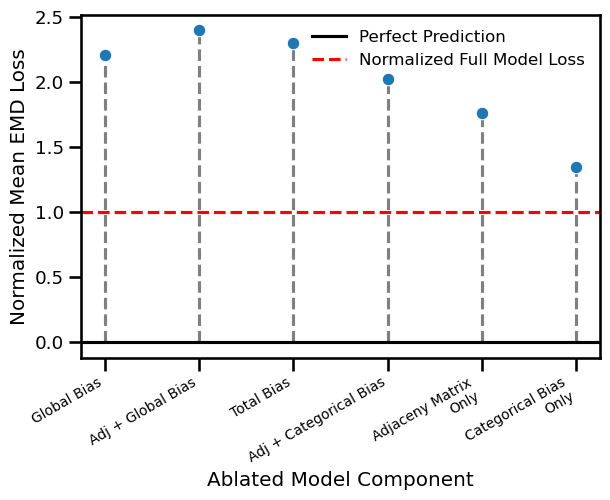

In [44]:
sns.set_context(
    "talk",
    font_scale=0.8,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(6, 5.1),
    constrained_layout=True
)

fig.get_layout_engine().set(w_pad=0.05, h_pad=0.15, wspace=0.0, hspace=0.0)

space = "Full Feature Space"
fold = 3

viz_df = emd_loss[emd_loss.Space == space].copy()
viz_df = viz_df[~viz_df["Model Components"].isin([ar_c['none']])].copy()
viz_df["Model Components"] = viz_df["Model Components"].cat.remove_unused_categories()

viz_df_fold = viz_df[viz_df.Fold == fold].copy()

sns.scatterplot(
    data=viz_df_fold,
    x="Model Components",
    y="Normalized Mean EMD Loss",
    ax=ax
)

ax.tick_params(axis="x", rotation=30, labelsize = 10)
for label in ax.get_xticklabels():
    label.set_ha("right")

ax.axhline(y=0, color="black", label="Perfect Prediction")
ax.axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")

for x, y in zip(
    viz_df_fold["Model Components"],
    viz_df_fold["Normalized Mean EMD Loss"]
):
    ax.vlines(x, ymin=0, ymax=y, linestyle="dashed", color="gray", zorder=0)

ax.set_xlabel("Ablated Model Component")
ax.set_ylabel("Normalized Mean EMD Loss")

# put legend inside so the axes don't get crushed
ax.legend(loc="upper right", frameon = False)

plt.show()
fig.savefig(os.path.join(fig_path, '{}_individual_component_loss.png'.format(author)), 
            dpi=1200, bbox_inches="tight")

In [46]:
cv_res_all = pd.read_csv(os.path.join(data_path, 'processed', '{}_biasPCA_probes.csv'.format(author)), index_col = 0)

bias_res_all = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_biases.pickle'.format(author))
)

bias_res_all_noadv = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_biases_noadv.pickle'.format(author))
)


cv_res_all.model_type = pd.Categorical(
    cv_res_all.model_type, 
    categories = ['linear', 'nonlinear'],
    ordered = True
).map(
    {
        'linear': 'Logistic Regression', 
        'nonlinear': 'Random Forest'}
)

cv_res_all.mod_type = pd.Categorical(
    cv_res_all.mod_type, 
    categories = ['actual', 'noadv'],
    ordered = True
).map(
    {
        'actual': 'scLEMBAS', 
        'noadv': 'No Adversarial Removal Baseline'}
)

def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

stats_res = collections.defaultdict(list)
for fold, classifier_type  in itertools.product(range(5), ['Logistic Regression', 'Random Forest']):
    mask = (cv_res_all.fold == fold) & (cv_res_all.bias_type == 'global') 
    mask = mask & (cv_res_all.model_type == classifier_type) 
    stats_df = cv_res_all[mask].copy()
    
    actual_mask = stats_df.mod_type == 'scLEMBAS'

    for col_label in [cat_col, pert_col]:
        a = stats_df[actual_mask]['{}_balanced_accuracy'.format(col_label)]
        b = stats_df[~actual_mask]['{}_balanced_accuracy'.format(col_label)]

        cd = cohens_d_paired(a,b)
        pval = stats.mannwhitneyu(a, b, alternative = 'less').pvalue

        stats_res['paired_cohen_d'].append(cd)
        stats_res['mwu_pval'].append(pval)

        stats_res['remove_type'].append(col_label)
        stats_res['classifier_type'].append(classifier_type)
        stats_res['fold'].append(fold)
    
stats_res = pd.DataFrame(stats_res)  
_, fdr, _, _ = multipletests(stats_res.mwu_pval, method = 'fdr_bh')
stats_res['bh_fdr'] = fdr

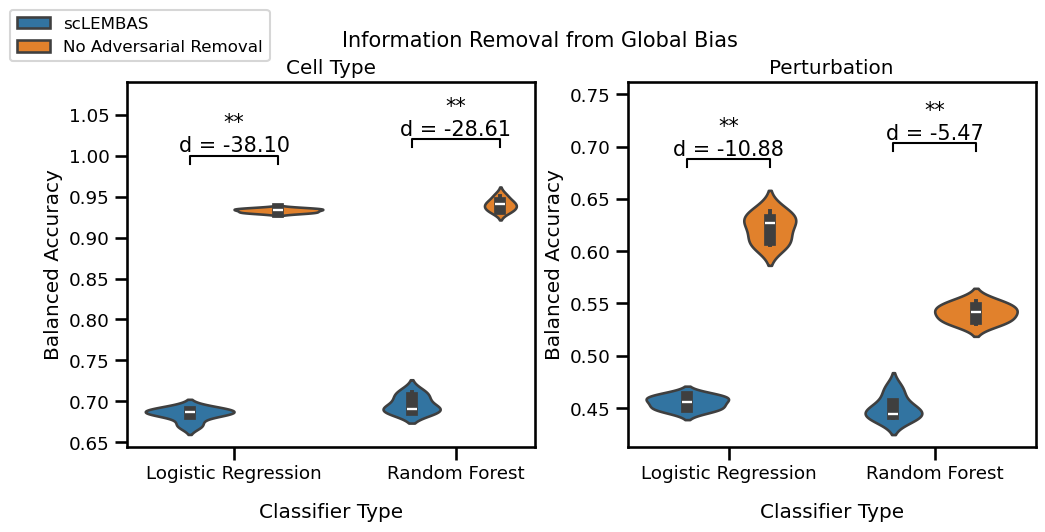

In [86]:
sns.set_context(
    "talk",
    font_scale=0.8,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

# ---- helper utilities ----
def _sig_stars(q):
    if q <= 0.001:
        return "***"
    elif q <= 0.01:
        return "**"
    elif q <= 0.05:
        return "*"
    else:
        return "ns"

def _add_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=15, clip_on=False)


# -------------------- MAIN --------------------

fold = 1  # Fold 2 (0-indexed)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5), constrained_layout=True)

chance_handle = None

mask = (cv_res_all.fold == fold) & (cv_res_all.bias_type == 'global') 
viz_df = cv_res_all[mask].copy()

split = get_split(fold, author)
test_cts = [s.split('^')[0] for s in split['test_conds']]
test_perts = [s.split('^')[1] for s in split['test_conds']]
random_ct = 1 / len(test_cts)
random_pert = 1 / len(test_perts)


for i, col_label in enumerate([cat_col, pert_col]):

    sns.violinplot(
        data=viz_df,
        x='model_type',
        y=f'{col_label}_balanced_accuracy',
        hue='mod_type',
        ax=ax[i]
    )

    ax[i].set_ylabel('Balanced Accuracy')
    ax[i].set_xlabel('Classifier Type', labelpad=15)

    # ---- bracket annotations ----
    _ycol = f'{col_label}_balanced_accuracy'

    _tick_pos = ax[i].get_xticks()
    _tick_lbls = [t.get_text() for t in ax[i].get_xticklabels()]
    _xmap = dict(zip(_tick_lbls, _tick_pos))

    _y0, _y1 = ax[i].get_ylim()
    _yrng = (_y1 - _y0) if (_y1 - _y0) != 0 else 0.1

    _brk_k = 0
    for _clf in _tick_lbls:
        _s = stats_res[
            (stats_res.fold == fold) &
            (stats_res.remove_type == col_label) &
            (stats_res.classifier_type == _clf)
        ]
        if _s.shape[0] == 0:
            continue

        _q = float(_s.bh_fdr.values[0])
        _d = float(_s.paired_cohen_d.values[0])
        _stars = _sig_stars(_q)

        _x = _xmap.get(_clf, None)
        if _x is None:
            continue

        _y = _y1 + (0.04 + 0.06 * _brk_k) * _yrng
        _h = 0.03 * _yrng
        _brk_k += 1

        _add_bracket(
            ax[i],
            _x - 0.20,
            _x + 0.20,
            _y,
            _h,
            "{}\nd = {:.2f}".format(_stars, _d)
        )

    ax[i].set_ylim(_y0, 0.02 + _y1 + (0.20 + 0.08 * max(_brk_k - 1, 0)) * _yrng)

    # ---- chance line ----
#     chance = random_ct if col_label == cat_col else random_pert

#     line = ax[i].axhline(
#         chance,
#         linestyle="--",
#         linewidth=2,
#         color="red",
#         alpha=0.9,
#         zorder=100
#     )
#     if chance_handle is None:
#         chance_handle = line

#     _y0, _y1 = ax[i].get_ylim()
#     ax[i].set_ylim(min(_y0, chance - 0.02), _y1)

    # ---- legend + titles ----
    leg = ax[i].get_legend()
    leg.set_title("Model Type")

    if i == 0:
        ax[i].set_title('Cell Type')
    else:
        ax[i].set_title('Perturbation')

#     if i == 1:
#         ylabel = ' '.join([cl.capitalize() for cl in col_label.split('_')])
#         ax_r = ax[i].twinx()
#         ax_r.set_ylabel(ylabel, labelpad=20)
#         ax_r.set_yticks([])
#         ax_r.tick_params(right=False)
#         ax_r.spines['right'].set_visible(False)

#     if i != 0:
#         ax[i].set_ylabel('')

#     if i != 1:
#         ax[i].set_xlabel('')
#         ax[i].tick_params(axis='x', which='both', labelbottom=False)

    if i != 0 and ax[i].get_legend() is not None:
        ax[i].legend_.remove()


# ---- shared legend ----
leg = ax[0].get_legend()
handles = leg.legend_handles # + [chance_handle]
labels = [t.get_text() for t in leg.get_texts()]# + ["Random Classifier Accuracy"]
labels[1] = 'No Adversarial Removal'
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=1,
    bbox_to_anchor=(0.1, 1.05)
)

ax[0].legend_.remove()

fig.suptitle('Information Removal from Global Bias', fontsize=15)
fig.savefig(os.path.join(fig_path, '{}_global_bias_removal.png'.format(author)), 
            dpi=1200, bbox_inches="tight")

In [93]:
def generate_umap(bias):
    X_umap = pd.DataFrame(bias.obsm['X_umap'], columns = ['UMAP{}'.format(i+1) for i in range(2)])

    nmis={}
    for col_type in [cat_col, pert_col]:
        col_label = ' '.join([cl.capitalize() for cl in col_type.split('_')])
        X_umap[col_label] = bias.obs[col_type].tolist()
        nmis[col_type] = normalized_mutual_info_score(bias.obs[col_type], bias.obs['TF_clusters'])
        
    return X_umap, nmis

''

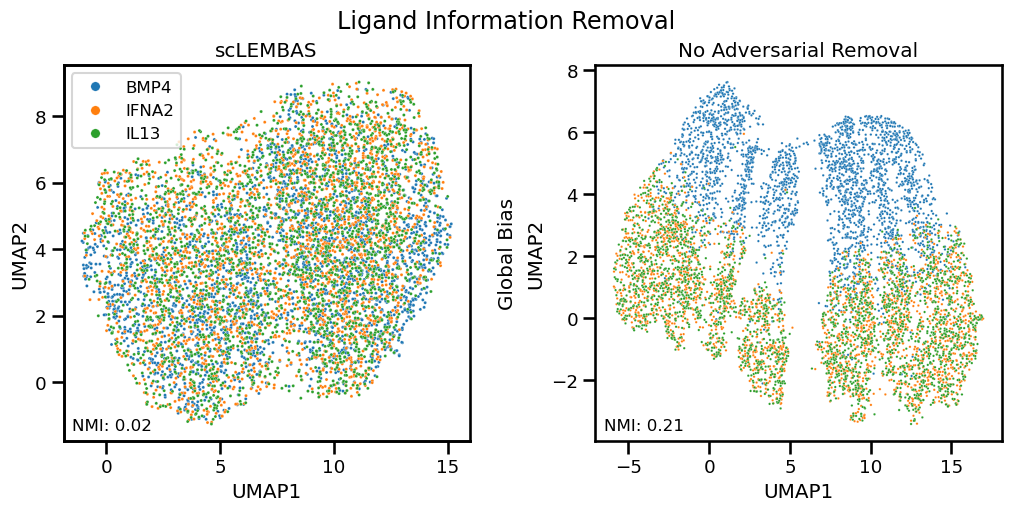

In [100]:
col_type = pert_col
sns.set_context(
    "talk",
    font_scale=0.8,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

fold = 1  # Fold 2 (0-indexed)

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    constrained_layout=True
)

col_label = ' '.join([cl.capitalize() for cl in col_type.split('_')])

# ----- Column 1: Global Bias -----
global_bias = bias_res_all[fold]['bias_embedded']['global']
bias_umap, bias_nmis = generate_umap(global_bias)

sns.scatterplot(
    data=bias_umap,
    x='UMAP1',
    y='UMAP2',
    hue=col_label,
    s=5,
    ax=ax[0]
)

ax[0].annotate(
    'NMI: {:.2f}'.format(bias_nmis[col_type]),
    xy=(0.02, 0.02),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=12
)

leg = ax[0].get_legend()
if leg is not None:
    leg.set_title(None)

ax[0].set_title('Fold: {}'.format(fold + 1))
ax[0].set_xlabel('')
ax[0].set_ylabel('')

ax_r = ax[0].twinx()
ax_r.set_ylabel('Global Bias', labelpad=20)
ax_r.set_yticks([])
ax_r.tick_params(right=False)
ax_r.spines['right'].set_visible(False)


# ----- Column 2: Global Bias, No Adversarial Removal -----
global_bias_noadv = bias_res_all_noadv[fold]['bias_embedded']['global']
bias_umap, bias_nmis = generate_umap(global_bias_noadv)

sns.scatterplot(
    data=bias_umap,
    x='UMAP1',
    y='UMAP2',
    hue=col_label,
    s=3,
    ax=ax[1]
)

ax[1].annotate(
    'NMI: {:.2f}'.format(bias_nmis[col_type]),
    xy=(0.02, 0.02),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=12
)

if ax[1].get_legend() is not None:
    ax[1].legend_.remove()

ax[0].legend(markerscale=3)

for i in range(2):
    ax[i].set_title('')
    ax[i].set_xlabel('UMAP1')
    ax[i].set_ylabel('UMAP2')
    ax[i].set_title('scLEMBAS' if i == 0 else 'No Adversarial Removal')


fig.suptitle('{} Information Removal'.format(col_label))
fig.savefig(os.path.join(fig_path, '{}_{}_global_bias_umap.png'.format(author, col_label)), 
            dpi=1200, bbox_inches="tight")
;

''

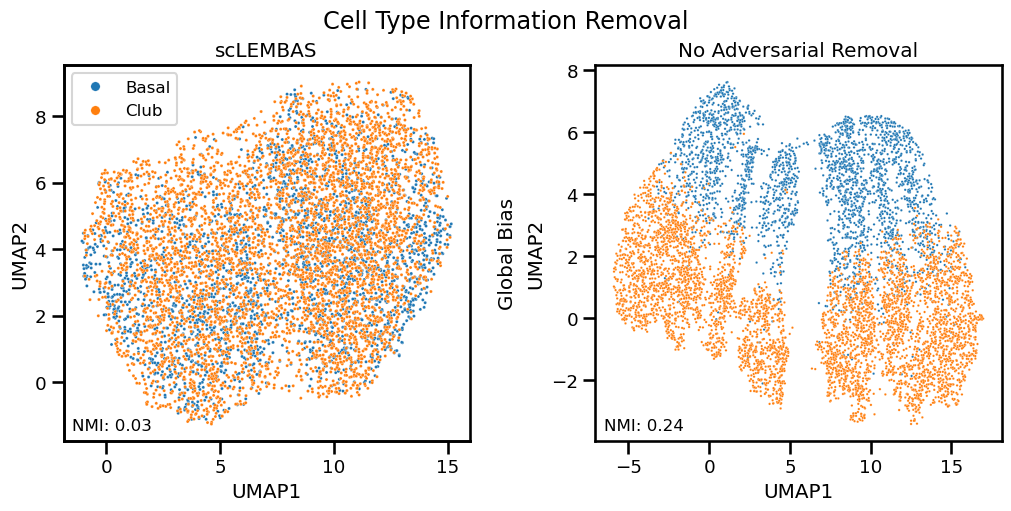

In [109]:
col_type = cat_col
sns.set_context(
    "talk",
    font_scale=0.8,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

fold = 1  # Fold 2 (0-indexed)

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    constrained_layout=True
)

col_label = ' '.join([cl.capitalize() for cl in col_type.split('_')])

# ----- Column 1: Global Bias -----
global_bias = bias_res_all[fold]['bias_embedded']['global']
bias_umap, bias_nmis = generate_umap(global_bias)

sns.scatterplot(
    data=bias_umap,
    x='UMAP1',
    y='UMAP2',
    hue=col_label,
    s=5,
    ax=ax[0]
)

ax[0].annotate(
    'NMI: {:.2f}'.format(bias_nmis[col_type]),
    xy=(0.02, 0.02),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=12
)

leg = ax[0].get_legend()
if leg is not None:
    leg.set_title(None)

ax[0].set_title('Fold: {}'.format(fold + 1))
ax[0].set_xlabel('')
ax[0].set_ylabel('')

ax_r = ax[0].twinx()
ax_r.set_ylabel('Global Bias', labelpad=20)
ax_r.set_yticks([])
ax_r.tick_params(right=False)
ax_r.spines['right'].set_visible(False)


# ----- Column 2: Global Bias, No Adversarial Removal -----
global_bias_noadv = bias_res_all_noadv[fold]['bias_embedded']['global']
bias_umap, bias_nmis = generate_umap(global_bias_noadv)

sns.scatterplot(
    data=bias_umap,
    x='UMAP1',
    y='UMAP2',
    hue=col_label,
    s=3,
    ax=ax[1]
)

ax[1].annotate(
    'NMI: {:.2f}'.format(bias_nmis[col_type]),
    xy=(0.02, 0.02),
    xycoords="axes fraction",
    ha="left",
    va="bottom",
    fontsize=12
)

if ax[1].get_legend() is not None:
    ax[1].legend_.remove()

ax[0].legend(markerscale=3)

for i in range(2):
    ax[i].set_title('')
    ax[i].set_xlabel('UMAP1')
    ax[i].set_ylabel('UMAP2')
    ax[i].set_title('scLEMBAS' if i == 0 else 'No Adversarial Removal')


fig.suptitle('{} Information Removal'.format(col_label))
fig.savefig(os.path.join(fig_path, '{}_ct_global_bias_umap.png'.format(author, col_label)), 
            dpi=1200, bbox_inches="tight")
;

In [5]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

cv_res_all = pd.read_csv(os.path.join(data_path, 'processed', '{}_biassubtypePCA_probes.csv'.format(author)), index_col = 0)
bias_res_subtypes = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_biasessubtypes.pickle'.format(author))
)
cv_res_all.model_type = pd.Categorical(
    cv_res_all.model_type, 
    categories = ['linear', 'nonlinear'],
    ordered = True
).map(
    {
        'linear': 'Logistic Regression', 
        'nonlinear': 'Random Forest'}
)

cv_res_all.mod_type = pd.Categorical(
    cv_res_all.mod_type, 
    categories = ['actual', 'noadv'],
    ordered = True
).map(
    {
        'actual': 'scLEMBAS', 
        'noadv': 'No Adversarial Removal Baseline'}
)

stats_res = collections.defaultdict(list)

for idx, bs in bias_res_subtypes.items():
    big_fold = bs['fold']
    ct = bs[cat_col]
    
    mask_ = (cv_res_all['{}_fold'.format(author)] == big_fold) & (cv_res_all[cat_col] == ct)
    for classifier_type  in (['Logistic Regression', 'Random Forest']):
        mask = mask_ & (cv_res_all['model_type'] == classifier_type)
        
        stats_df = cv_res_all[mask].copy()
        actual_mask = (stats_df.mod_type == 'scLEMBAS')
        
        a = stats_df[actual_mask]['{}_balanced_accuracy'.format('secretory_mcc_subsets')]
        b = stats_df[~actual_mask]['{}_balanced_accuracy'.format('secretory_mcc_subsets')]

        cd = cohens_d_paired(a,b)
        pval = stats.wilcoxon(a, b, alternative = 'two-sided').pvalue# stats.mannwhitneyu(a, b, alternative = 'two-sided').pvalue

        stats_res['paired_cohen_d'].append(cd)
        stats_res['mwu_pval'].append(pval)

        stats_res[cat_col].append(ct)
        stats_res['classifier_type'].append(classifier_type)
        stats_res['fold'].append(big_fold) 
        
#         test.append(stats_df)
        
stats_res = pd.DataFrame(stats_res)  
_, fdr, _, _ = multipletests(stats_res.mwu_pval, method = 'fdr_bh')
stats_res['bh_fdr'] = fdr


/tmp/ipykernel_334719/1551515428.py:93: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.16, top=0.82)


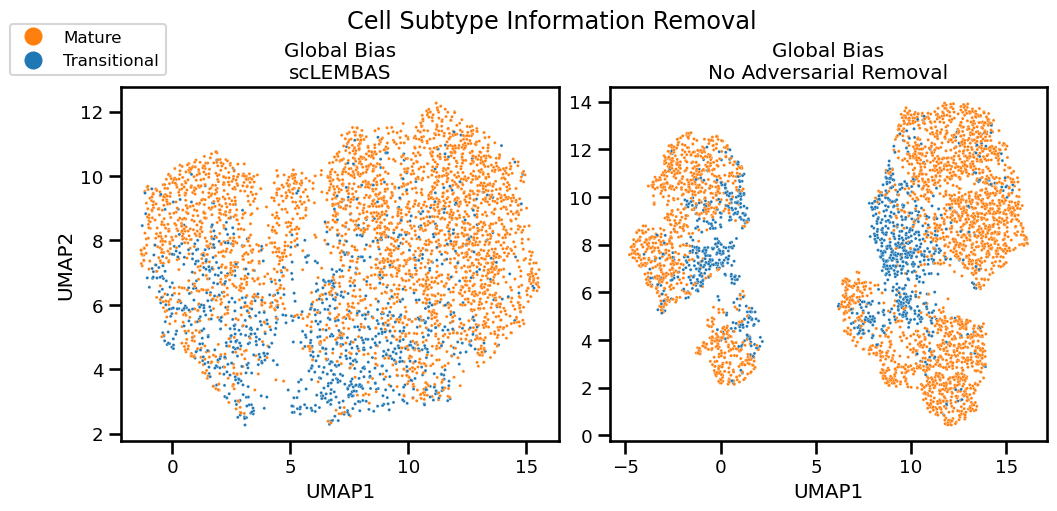

In [18]:
sns.set_context(
    "talk",
    font_scale=0.8,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)

from matplotlib.lines import Line2D

mod_type_map = {
    'actual': 'Global Bias\nscLEMBAS',
    'noadv': 'Global Bias\nNo Adversarial Removal'
}


def generate_umap(bias):
    X_umap = pd.DataFrame(
        bias.obsm['X_umap'],
        columns=['UMAP{}'.format(i + 1) for i in range(2)]
    )

    vals = pd.Series(bias.obs['secretory_mcc_subsets'].astype(str)).str.lower()

    cleaned_vals = np.where(
        vals.str.contains('mature'),
        'Mature',
        np.where(
            vals.str.contains('transitional'),
            'Transitional',
            bias.obs['secretory_mcc_subsets'].astype(str)
        )
    )

    X_umap['Cell Subtype'] = cleaned_vals 
    nmis = {}
    nmis['secretory_mcc_subsets'] = normalized_mutual_info_score(
        cleaned_vals,
        bias.obs['TF_clusters']
    )

    return X_umap, nmis


col_label = 'Cell Subtype'



# ---------------------------
# organize entries
# ---------------------------
plot_items = []
for idx, bs in bias_res_subtypes.items():
    plot_items.append({
        'fold': bs['fold'],
        'cell_type': bs[cat_col],
        'mod_type': bs['mod_type'],
        'anndata_obj': bs['anndata_obj'],
    })

plot_df = pd.DataFrame(plot_items)

# fold-celltype combinations from original multi-panel layout
col_combos = (
    plot_df[['fold', 'cell_type']]
    .drop_duplicates()
    .sort_values(['fold', 'cell_type'])
    .reset_index(drop=True)
)

# mod types become the two columns
col_mod_types = sorted(plot_df['mod_type'].unique())

assert len(col_mod_types) == 2
assert len(col_combos) >= 2

# ---------------------------
# keep only the current second column
# ---------------------------
selected_combo_idx = 1
selected_combo = col_combos.iloc[selected_combo_idx]
fold = selected_combo['fold']
ct = selected_combo['cell_type']

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    constrained_layout=True
)

fig.subplots_adjust(left=0.16, top=0.82)

ax = np.array(ax).reshape(2)

palette = {
    'Transitional': sns.color_palette()[0],  # first color
    'Mature': sns.color_palette()[1],
}

for j, mod_type in enumerate(col_mod_types):
    curr = plot_df[
        (plot_df['fold'] == fold) &
        (plot_df['cell_type'] == ct) &
        (plot_df['mod_type'] == mod_type)
    ]

    assert curr.shape[0] == 1

    bias_obj = curr.iloc[0]['anndata_obj']
    bias_umap, bias_nmis = generate_umap(bias_obj)

    sns.scatterplot(
        data=bias_umap,
        x='UMAP1',
        y='UMAP2',
        hue='Cell Subtype',
        hue_order=['Transitional', 'Mature'],
        palette=palette,
        s=5,
        ax=ax[j],
        legend=False
    )

#     ax[j].annotate(
#         'NMI: {:.2f}'.format(bias_nmis['secretory_mcc_subsets']),
#         xy=(0.02, 0.02),
#         xycoords="axes fraction",
#         ha="left",
#         va="bottom",
#         fontsize=12
#     )

    # panel titles are the former right-side row labels
    ax[j].set_title(mod_type_map[mod_type])

    if j != 0:
        ax[j].set_ylabel('')

# ---------------------------
# figure-level legend (upper left, one column)
# ---------------------------
handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=palette['Mature'],
        label='Mature',
        markersize=12
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=palette['Transitional'],
        label='Transitional',
        markersize=12
    ),
]

fig.legend(
    handles=handles,
    loc='upper left',
    ncol=1,
    bbox_to_anchor=(-0.05, 0.98),
)

fig.suptitle('Cell Subtype Information Removal')
fig.savefig(os.path.join(fig_path, '{}_cellsubtype_global_bias_umap.png'.format(author)), 
            dpi=1200, bbox_inches="tight")

plt.show()

In [29]:
fn = os.path.join(data_path, 'processed', 'subtype_distance_quantification_with_predictions.csv')
distances_res_actual = pd.read_csv(fn, index_col = 0)

fn = os.path.join(data_path, 'processed', 'subtype_distance_quantification_with_predictions_random.csv')
distances_res_rand = pd.read_csv(fn, index_col = 0)


same_cols = ['cell_type', 'origin_pert', 'target_pert', 'fold']
assert distances_res_rand[same_cols].equals(distances_res_actual[same_cols])
distances_res = pd.concat([distances_res_actual, distances_res_rand], ignore_index = True)

def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)


mt_map = {
    'actual': 'scLEMBAS', 
    'random': 'Random'
}

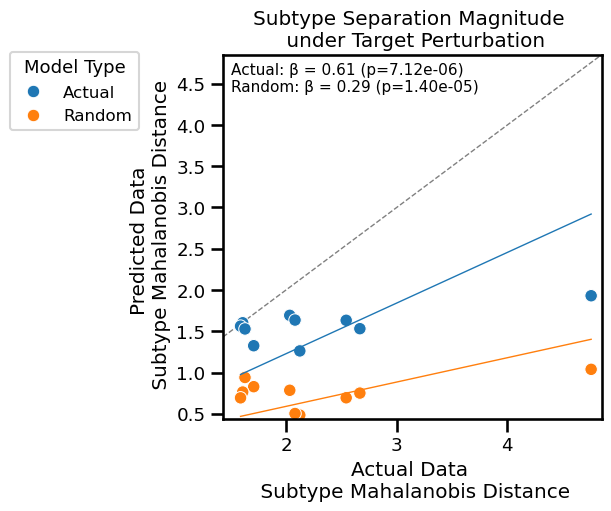

In [30]:
metric = 'mahanalobis'


if metric == 'mahanalobis':
    y_label = 'target_predicted_md'
    x_label = 'target_actual_md'
elif metric == 'euclidean':
    y_label = 'target_predicted_ed'
    x_label = 'target_actual_ed'
    
distances_res['error'] = np.abs(distances_res[y_label] - distances_res[x_label]) # / np.sqrt(2)




sns.set_context(
    "talk",
    font_scale=0.8,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)


fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# -------------------- SCATTER --------------------
sns.scatterplot(
    data=distances_res,
    x=x_label,
    y=y_label,
    hue='mod_type',
    ax=ax,
    zorder=2
)

# -------------------- FIT LINES --------------------
for mod_type in ['actual', 'random']:
    viz_df = distances_res[distances_res.mod_type == mod_type]

    x = viz_df[x_label].values
    y = viz_df[y_label].values

    res = sm.OLS(y, x).fit()
    beta = res.params[0]

    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = beta * x_line

    ax.plot(x_line, y_line, linewidth=1, label=f'{mod_type} fit')


# -------------------- STATS --------------------
# actual
x = distances_res[distances_res.mod_type == 'actual'][x_label].values
y = distances_res[distances_res.mod_type == 'actual'][y_label].values
res = sm.OLS(y, x).fit()
beta_actual = res.params[0]
pval_actual = res.pvalues[0]

# random
x = distances_res[distances_res.mod_type == 'random'][x_label].values
y = distances_res[distances_res.mod_type == 'random'][y_label].values
res = sm.OLS(y, x).fit()
beta_random = res.params[0]
pval_random = res.pvalues[0]

ax.text(
    0.02, 0.98,
    "{}: β = {:.2f} (p={:.2e})\n{}: β = {:.2f} (p={:.2e})".format(
        'Actual', beta_actual, pval_actual,
        'Random', beta_random, pval_random
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
)

# -------------------- AXES --------------------
ax.set_xlabel('Actual Data \n Subtype Mahalanobis Distance')
ax.set_ylabel('Predicted Data \n Subtype Mahalanobis Distance')

x_min, x_max = distances_res[x_label].min(), distances_res[x_label].max()
y_min, y_max = distances_res[y_label].min(), distances_res[y_label].max()

x_min *= 0.9
y_min *= 0.9
ax_max = max(y_max, x_max) * 1.02

ax.set_xlim(x_min, ax_max)
ax.set_ylim(y_min, ax_max)

# identity line
diag_min = max(x_min, y_min)

ax.plot(
    [diag_min, ax_max],
    [diag_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)

# -------------------- LEGEND --------------------
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles[:2],
    labels=['Actual', 'Random'],
    title='Model Type',
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)

# -------------------- TITLE --------------------
ax.set_title('Subtype Separation Magnitude \n under Target Perturbation')
fig.savefig(os.path.join(fig_path, '{}_subtype_mahalanobis.png'.format(author)), 
            dpi=1200, bbox_inches="tight")

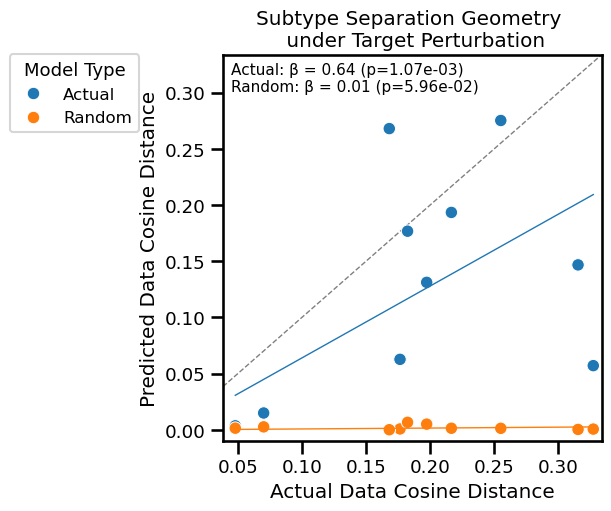

In [31]:
x_label = 'cosine_actual'
y_label = 'cosine_predicted'
distances_res['error'] = np.abs(distances_res[y_label] - distances_res[x_label]) # / np.sqrt(2)


fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# -------------------- SCATTER --------------------
sns.scatterplot(
    data=distances_res,
    x=x_label,
    y=y_label,
    hue='mod_type',
    ax=ax,
    zorder=2
)

# -------------------- FIT LINES --------------------
for mod_type in ['actual', 'random']:
    viz_df = distances_res[distances_res.mod_type == mod_type]

    x = viz_df[x_label].values
    y = viz_df[y_label].values

    res = sm.OLS(y, x).fit()
    beta = res.params[0]

    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = beta * x_line

    ax.plot(x_line, y_line, linewidth=1, label=f'{mod_type} fit')

# -------------------- STATS --------------------
# actual
x = distances_res[distances_res.mod_type == 'actual'][x_label].values
y = distances_res[distances_res.mod_type == 'actual'][y_label].values
res = sm.OLS(y, x).fit()
beta_actual = res.params[0]
pval_actual = res.pvalues[0]

# random
x = distances_res[distances_res.mod_type == 'random'][x_label].values
y = distances_res[distances_res.mod_type == 'random'][y_label].values
res = sm.OLS(y, x).fit()
beta_random = res.params[0]
pval_random = res.pvalues[0]

ax.text(
    0.02, 0.98,
    "{}: β = {:.2f} (p={:.2e})\n{}: β = {:.2f} (p={:.2e})".format(
        'Actual', beta_actual, pval_actual,
        'Random', beta_random, pval_random
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
)

# -------------------- AXES --------------------
ax.set_xlabel('Actual Data Cosine Distance')
ax.set_ylabel('Predicted Data Cosine Distance')

x_min, x_max = distances_res[x_label].min(), distances_res[x_label].max()
y_min, y_max = distances_res[y_label].min(), distances_res[y_label].max()

x_min *= 0.8
y_min = -0.01
ax_max = max(y_max, x_max) * 1.02

ax.set_xlim(x_min, ax_max)
ax.set_ylim(y_min, ax_max)

# identity line
diag_min = max(x_min, y_min)

ax.plot(
    [diag_min, ax_max],
    [diag_min, ax_max],
    linestyle="--",
    color="gray",
    linewidth=1,
    zorder=0
)

# -------------------- LEGEND --------------------
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles[:2],
    labels=['Actual', 'Random'],
    title='Model Type',
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)

# -------------------- TITLE --------------------
ax.set_title('Subtype Separation Geometry \n under Target Perturbation')
fig.savefig(os.path.join(fig_path, '{}_subtype_cosine.png'.format(author)), 
            dpi=1200, bbox_inches="tight")

In [33]:
os.path.join(fig_path, '{}_subtype_cosine.png'.format(author))

'/home/hmbaghda/orcd/pool/scLEMBAS/analysis/figures/presenting/McCauley_subtype_cosine.png'

# Kang

In [82]:
author = 'Kang'
cat_col = 'seurat_annotations'
pert_col = 'stim'
ctrl_pert = None

from notebook_utils import get_split, load_test_tfadata, clear_adata

sys.path.insert(1, '/home/hmbaghda/Projects/scLEMBAS/notebooks/Kang_2017/') 
from Kang_utils import pca_mod, rev_stim

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', '{}_tf_activity.h5ad').format(author))
tf_adata.obs['condition'] = tf_adata.obs[cat_col].astype(str) + '^' + tf_adata.obs[pert_col].astype(str)
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

In [83]:
tf_adata.obs[pert_col] = pd.Categorical(tf_adata.obs[pert_col], 
                                       categories = ['STIM', ''])

''

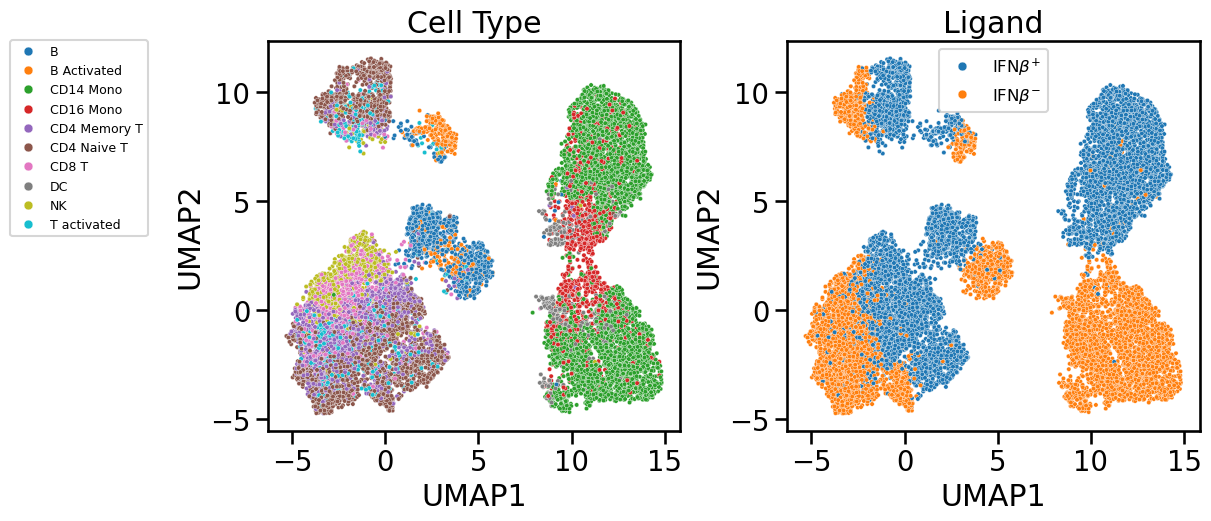

In [55]:
ncols, nrows = 2,1
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12, 5.1*nrows), constrained_layout = True)
ax = np.array(axes).reshape(nrows, ncols)
# ax = axes if isinstance(axes, np.ndarray) else np.array([axes])
# ax = ax.flatten()
plot_type = 'scatter'

ll_map = {'umap': ''}#'PCA-Derived UMAP', 

for i, latent_label in enumerate(['umap']):
    viz_df = pd.DataFrame(tf_adata.obsm['X_' + latent_label])
    _label_name = 'UMAP'
    viz_df.columns = [_label_name + '{}'.format(i+1) for i in range(viz_df.shape[1])]
    
    for covariate in [cat_col, pert_col]:
        viz_df[covariate] = tf_adata.obs[covariate].reset_index(drop=True)
    
    viz_df = viz_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    
    for (j, covariate) in enumerate([cat_col, pert_col]):
        if plot_type == 'scatter':
            if j == 1:
                viz_df[covariate] = viz_df[covariate].cat.rename_categories({
                    "STIM": r"$\mathrm{IFN}\beta^{+}$", 
                    "CTRL": r"$\mathrm{IFN}\beta^{-}$"
                })
                order = viz_df[covariate].cat.categories[::-1]
            else:
                order = viz_df[covariate].cat.categories
            sns.scatterplot(data = viz_df, 
                            x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                            ax = ax[i, j], s = 10, 
                            hue_order = order
                           )
        elif plot_type == 'contour':
            sns.kdeplot(data = viz_df, 
                        x = _label_name + '{}'.format(1), y = _label_name + '{}'.format(2), hue = covariate,
                        ax = ax[i, j], fill = False, levels = 5)
        
        
        if ax[i,j].legend_ is not None and i != 0:
            ax[i,j].legend_.remove()
        else:
            title = ax[i, j].get_legend().get_title().get_text()
            ax[i, j].legend(title=None, markerscale=2)#' '.join([c.capitalize() for c in title.split('_')]))
            
        if j == 0:  # first panel only
            leg = ax[i, j].get_legend()
            ax[i, j].legend(
                title=None,
                loc='center right',
                bbox_to_anchor=(-0.275, 0.75),  # push to the left, outside
                markerscale=2,
                fontsize=9,
            )
            ax[i,j].set_title('Cell Type')
        else:
            ax[i,j].set_title('Ligand')
        
fig.savefig(os.path.join(fig_path, '{}_TF_filtered_umap_visualization.png'.format(author)), 
            dpi=1200, bbox_inches="tight")
;

In [84]:
merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)



In [55]:
ls_label_dict = {
    'pls': 'PLS', 
    'pca': 'PC'
}




def plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde = 75, is_last_col = False):

    adata_dict = {
        'Actual': tf_adata_actual,
        'Predicted': tf_adata_predicted
    }

    cats = None

    for (i, (adata_type, adata)) in enumerate(adata_dict.items()):

        viz_df = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
        viz_df.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df.shape[1])]

        viz_df[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()

        viz_df[group_col] = viz_df[group_col].str.replace(r', CTRL$', ', IFN\u03B2\u207B', regex=True)
        viz_df[group_col] = viz_df[group_col].str.replace(r', STIM$', ', IFN\u03B2\u207A', regex=True)
        cats = sorted(viz_df[group_col].unique())
        viz_df[group_col] = pd.Categorical(
            viz_df[group_col],
            categories=cats,
            ordered=True
        )

        # --- KDE for groups that can support it; scatter fallback for tiny / singular groups ---

        small_cats = []
        for cat in cats:
            tmp = viz_df[viz_df[group_col] == cat]

            # too few points
            if tmp.shape[0] < min_points_kde:
                small_cats.append(cat)
                continue

            # singular / near-singular geometry (no 2D contour possible)
            xvar = np.var(tmp['{}1'.format(ls_label_dict[ls])].values)
            yvar = np.var(tmp['{}2'.format(ls_label_dict[ls])].values)
            if (xvar <= 1e-12) or (yvar <= 1e-12):
                small_cats.append(cat)

        viz_df_kde = viz_df[~viz_df[group_col].isin(small_cats)]

        if viz_df_kde.shape[0] > 0:
            sns.kdeplot(data = viz_df_kde,
                        x = '{}1'.format(ls_label_dict[ls]),
                        y = '{}2'.format(ls_label_dict[ls]),
                        hue = group_col, fill = False, levels = 5,
                        warn_singular = False,
                        ax = ax[i])

        # scatter overlay for small / singular groups (so they never disappear)
        palette = sns.color_palette(n_colors = len(cats))
        color_map = {cat: color for (cat, color) in zip(cats, palette)}

        for cat in small_cats:
            tmp = viz_df[viz_df[group_col] == cat]
            ax[i].scatter(tmp['{}1'.format(ls_label_dict[ls])],
                          tmp['{}2'.format(ls_label_dict[ls])],
                          s = 12, alpha = 0.9,
                          color = color_map[cat])

        # titles: only top row
        if i == 0:
            ax[i].set_title('Fold: {}'.format(fold + 1))
        else:
            ax[i].set_title('')

        # clear seaborn auto-legend
        ax[i].legend_.remove() if ax[i].legend_ is not None else None

        # right-side y-axis labels only on final column
#         if is_last_col:
#             ax_r = ax[i].twinx()                 
#             ax_r.set_ylabel(adata_type, labelpad = 20)
#             ax_r.set_yticks([])              
#             ax_r.tick_params(right=False)
#             ax_r.spines['right'].set_visible(False)
#         else:
#             ax[i].set_ylabel('')

    # ensure smae bounds (robust quantiles)
    xmin, xmax, ymin, ymax = np.inf, -np.inf, np.inf, -np.inf

    q_lo = 0.005
    q_hi = 0.995

    for (adata_type, adata) in adata_dict.items():
        X = adata.obsm['X_{}'.format(ls)]

        x_lo = np.quantile(X[:, 0], q_lo)
        x_hi = np.quantile(X[:, 0], q_hi)
        y_lo = np.quantile(X[:, 1], q_lo)
        y_hi = np.quantile(X[:, 1], q_hi)

        if x_lo < xmin:
            xmin = x_lo
        if x_hi > xmax:
            xmax = x_hi
        if y_lo < ymin:
            ymin = y_lo
        if y_hi > ymax:
            ymax = y_hi

    # small padding
    pad = 0.15
    dx = (xmax - xmin) * pad
    dy = (ymax - ymin) * pad
    xmin = xmin - dx
    xmax = xmax + dx
    ymin = ymin - dy
    ymax = ymax + dy

    for j in range(2):
        ax[j].set_xlim(xmin, xmax)
        ax[j].set_ylim(ymin, ymax)

    # legend (only once per column, on top axis)
    handles = []
    labels = []
    palette = sns.color_palette(n_colors = len(cats))
    for color, cat in zip(palette, cats):
        handles.append(Line2D([0], [0], color = color, lw = 2))
        labels.append(cat)
    ax[0].legend(handles = handles, labels = labels, title = '')

    return cats

def pca_projections(tf_adata_actual, tf_adata_predicted, baseline = False):    
    if not baseline:
        tf_adata_actual = clear_adata(tf_adata_actual)
        tf_adata_predicted = clear_adata(tf_adata_predicted)
    
    X_actual_pca = ls.project_to_pca(tf_adata_actual.X, tf_adata)
    tf_adata_actual.obsm['X_pca'] = X_actual_pca
    
    X_pred_pca = ls.project_to_pca(tf_adata_predicted.X, tf_adata)
    tf_adata_predicted.obsm['X_pca'] = X_pred_pca
    
    return tf_adata_actual, tf_adata_predicted

# # redfine plotting with this additional step
# def plot_fold_column(fold, ls, group_col, ax, min_points_kde = 75, is_last_col = False):
#     tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, author, merged_adatas, tf_adata)
#     tf_adata_actual, tf_adata_predicted = pca_projections(tf_adata_actual, tf_adata_predicted, baseline = False)
#     cats = plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
#                      ls, group_col, ax, min_points_kde, is_last_col)
#     return cats

def plot_fold_column(fold, ls, group_col, ax, min_points_kde=75, is_last_col=False):
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, author, merged_adatas, tf_adata)
    tf_adata_actual, tf_adata_predicted = pca_projections(tf_adata_actual, tf_adata_predicted, baseline=False)
    cats, handles, labels, palette = plot_fold_column_(
        tf_adata_actual, tf_adata_predicted,
        ls, group_col, ax, min_points_kde, is_last_col
    )
    return cats, handles, labels, palette


def legend_last_char_big(ax, cats, colors, loc="upper left",
                         base_fs=11, last_fs=16, sep=2,
                         frameon=True, alpha=0.3):
    rows = []

    for cat, color in zip(cats, colors):
        cat = "" if cat is None else str(cat)
        if len(cat) == 0:
            prefix, last = "", ""
        else:
            prefix, last = cat[:-1], cat[-1]

        # line sample
        da = DrawingArea(18, 10, 0, 0)
        da.add_artist(Line2D([0, 18], [5, 5], color=color, lw=2))

        # label: prefix + larger last character
        t_prefix = TextArea(prefix, textprops=dict(size=base_fs))
        t_last   = TextArea(last,   textprops=dict(size=last_fs))
        label = HPacker(children=[t_prefix, t_last], align="baseline", pad=0, sep=0)

        row = HPacker(children=[da, label], align="center", pad=0, sep=6)
        rows.append(row)

    box = VPacker(children=rows, align="left", pad=0, sep=sep)
    anchored = AnchoredOffsetbox(loc=loc, child=box, frameon=frameon, borderpad=0.4)
    ax.add_artist(anchored)

    if frameon:
        anchored.patch.set_alpha(alpha)

    return anchored


def plot_fold_column_(tf_adata_actual, tf_adata_predicted, 
                     ls, group_col, ax, min_points_kde = 75, is_last_col = False):

    adata_dict = {
        'Actual': tf_adata_actual,
        'Predicted': tf_adata_predicted
    }

    cats = None

    for (i, (adata_type, adata)) in enumerate(adata_dict.items()):

        viz_df = pd.DataFrame(adata.obsm['X_{}'.format(ls)])
        viz_df.columns = ['{}{}'.format(ls_label_dict[ls], i+1) for i in range(viz_df.shape[1])]

        viz_df[group_col] = adata.obs[group_col].astype(str).apply(lambda x: x.replace('^', ', ')).tolist()

        viz_df[group_col] = viz_df[group_col].str.replace(r', CTRL$', ', IFN\u03B2\u207B', regex=True)
        viz_df[group_col] = viz_df[group_col].str.replace(r', STIM$', ', IFN\u03B2\u207A', regex=True)
        cats = sorted(viz_df[group_col].unique())
        viz_df[group_col] = pd.Categorical(
            viz_df[group_col],
            categories=cats,
            ordered=True
        )

        # --- KDE for groups that can support it; scatter fallback for tiny / singular groups ---

        small_cats = []
        for cat in cats:
            tmp = viz_df[viz_df[group_col] == cat]

            # too few points
            if tmp.shape[0] < min_points_kde:
                small_cats.append(cat)
                continue

            # singular / near-singular geometry (no 2D contour possible)
            xvar = np.var(tmp['{}1'.format(ls_label_dict[ls])].values)
            yvar = np.var(tmp['{}2'.format(ls_label_dict[ls])].values)
            if (xvar <= 1e-12) or (yvar <= 1e-12):
                small_cats.append(cat)

        viz_df_kde = viz_df[~viz_df[group_col].isin(small_cats)]

        if viz_df_kde.shape[0] > 0:
            sns.kdeplot(data = viz_df_kde,
                        x = '{}1'.format(ls_label_dict[ls]),
                        y = '{}2'.format(ls_label_dict[ls]),
                        hue = group_col, fill = False, levels = 5,
                        warn_singular = False,
                        ax = ax[i])

        # scatter overlay for small / singular groups (so they never disappear)
        palette = sns.color_palette(n_colors = len(cats))
        color_map = {cat: color for (cat, color) in zip(cats, palette)}

        for cat in small_cats:
            tmp = viz_df[viz_df[group_col] == cat]
            ax[i].scatter(tmp['{}1'.format(ls_label_dict[ls])],
                          tmp['{}2'.format(ls_label_dict[ls])],
                          s = 12, alpha = 0.9,
                          color = color_map[cat])

        # titles: only top row
        if i == 0:
            ax[i].set_title('Fold: {}'.format(fold + 1))
        else:
            ax[i].set_title('')

        # clear seaborn auto-legend
        ax[i].legend_.remove() if ax[i].legend_ is not None else None

#         # right-side y-axis labels only on final column
#         if is_last_col:
#             ax_r = ax[i].twinx()                 
#             ax_r.set_ylabel(adata_type, labelpad = 20)
#             ax_r.set_yticks([])              
#             ax_r.tick_params(right=False)
#             ax_r.spines['right'].set_visible(False)
#         else:
#             ax[i].set_ylabel('')

    # ensure smae bounds (robust quantiles)
    xmin, xmax, ymin, ymax = np.inf, -np.inf, np.inf, -np.inf

    q_lo = 0.005
    q_hi = 0.995

    for (adata_type, adata) in adata_dict.items():
        X = adata.obsm['X_{}'.format(ls)]

        x_lo = np.quantile(X[:, 0], q_lo)
        x_hi = np.quantile(X[:, 0], q_hi)
        y_lo = np.quantile(X[:, 1], q_lo)
        y_hi = np.quantile(X[:, 1], q_hi)

        if x_lo < xmin:
            xmin = x_lo
        if x_hi > xmax:
            xmax = x_hi
        if y_lo < ymin:
            ymin = y_lo
        if y_hi > ymax:
            ymax = y_hi

    # small padding
    pad = 0.15
    dx = (xmax - xmin) * pad
    dy = (ymax - ymin) * pad
    xmin = xmin - dx
    xmax = xmax + dx
    ymin = ymin - dy
    ymax = ymax + dy

    for j in range(2):
        ax[j].set_xlim(xmin, xmax)
        ax[j].set_ylim(ymin, ymax)

    # legend (only once per column, on top axis)
    handles = []
    labels = []
    palette = sns.color_palette(n_colors = len(cats))
    for color, cat in zip(palette, cats):
        handles.append(Line2D([0], [0], color = color, lw = 2))
        labels.append(cat)
    
#     ax[0].legend(handles = handles, labels = labels, title = '')
#     legend_last_char_big(ax[0], cats, palette, base_fs=11, last_fs=18, loc="upper left", alpha = 0.3)

    return cats, handles, labels, palette

In [56]:
# ncols = 1  # n_folds
# fig, ax = plt.subplots(
#     nrows=2,
#     ncols=ncols,
#     figsize=(5 * ncols, 8),
#     constrained_layout=True
# )

# # ensure 2D
# if ncols == 1:
#     ax = np.array(ax).reshape(2, 1)

# legend_handles, legend_labels, legend_palette = None, None, None

# for fold in range(ncols):
#     cats, handles, labels, palette = plot_fold_column(
#         fold=fold,
#         ls='pca',
#         group_col='condition',
#         ax=ax[:, fold],
#         min_points_kde=50,
#         is_last_col=(fold == ncols - 1)
#     )
#     if fold == 0:
#         legend_handles, legend_labels, legend_palette = handles, labels, palette

# # labeling
# for i in range(ax.shape[0]):
#     for j in range(ax.shape[1]):
#         if i == 0:
#             ax[i, j].set_title('Actual')
#         else:
#             ax[i, j].set_title('Predicted')
#         if j == 0:
#             ax[i, j].set_ylabel('PC2')
#         else:
#             ax[i, j].set_ylabel('')
#         if i == ax.shape[0] - 1:
#             ax[i, j].set_xlabel('PC1')
#         else:
#             ax[i, j].set_xlabel('')

# for i in range(2):
#     if hasattr(ax[i, 0], 'right_ax'):
#         twin_ax = ax[i, 0].right_ax
#         twin_ax.set_ylabel('')
#         twin_ax.set_yticks([])
#         twin_ax.tick_params(right=False, labelright=False)

# fig.legend(
#     legend_handles, legend_labels,
#     loc='center left',
#     bbox_to_anchor=(-0.6, 0.8),      # negative x pushes it left of the first panel
#     bbox_transform=ax[0, 0].transAxes, # coords relative to the first panel's axes
#     frameon=True,
# #     framealpha=0.3,
#     title=''
# )

# fig.savefig(os.path.join(fig_path, '{}_predictions_fold1.png'.format(author)),
#             dpi=1200, bbox_inches="tight")

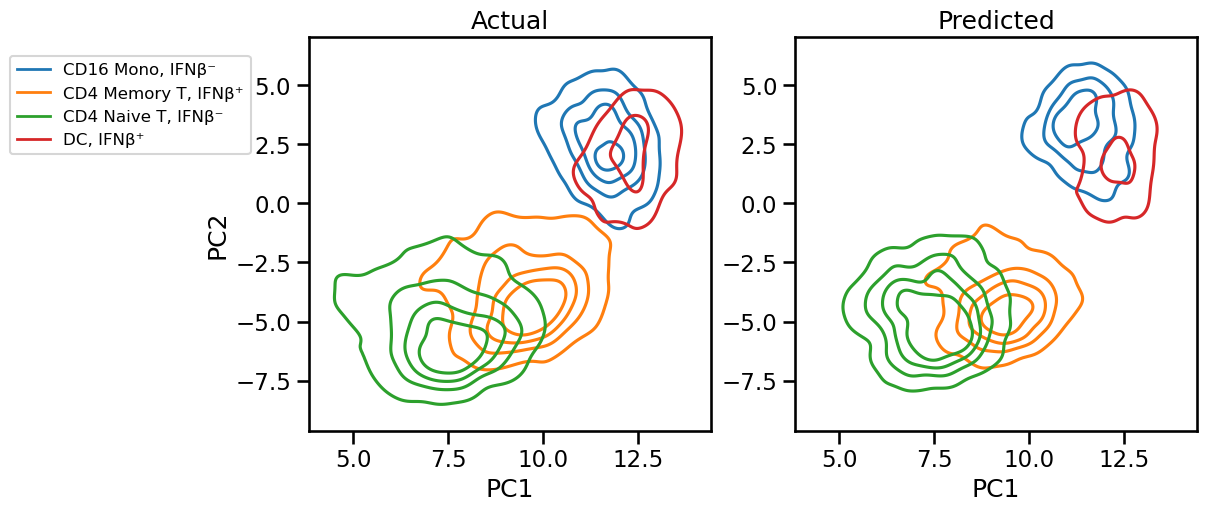

In [58]:
sns.set_context(
    "talk",
    font_scale=1,
    rc={
        "legend.fontsize": 12,
        "legend.title_fontsize": 13,
    }
)


ncols = 2
nrows = 1

fig, ax = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(10, 5),
    constrained_layout=True
)

# ensure 2D
ax = np.array(ax).reshape(nrows, ncols)

legend_handles, legend_labels, legend_palette = None, None, None

# single fold now → pass both columns
cats, handles, labels, palette = plot_fold_column(
    fold=0,
    ls='pca',
    group_col='condition',
    ax=ax[0, :],   # <-- key change
    min_points_kde=50,
    is_last_col=True
)

legend_handles, legend_labels, legend_palette = handles, labels, palette

# labeling (now iterate over columns only)
for j in range(ax.shape[1]):
    if j == 0:
        ax[0, j].set_title('Actual')
        ax[0, j].set_ylabel('PC2')
    else:
        ax[0, j].set_title('Predicted')
        ax[0, j].set_ylabel('')

    ax[0, j].set_xlabel('PC1')

# remove twin axes (now iterate over columns)
for j in range(2):
    if hasattr(ax[0, j], 'right_ax'):
        twin_ax = ax[0, j].right_ax
        twin_ax.set_ylabel('')
        twin_ax.set_yticks([])
        twin_ax.tick_params(right=False, labelright=False)

# figure legend (same)
fig.legend(
    legend_handles, legend_labels,
    loc='center left',
    bbox_to_anchor=(-0.2, 0.8),   # adjust for horizontal layout
    frameon=True,
    title=''
)

fig.savefig(
    os.path.join(fig_path, f'{author}_predictions_fold1.png'),
    dpi=1200,
    bbox_inches="tight"
)

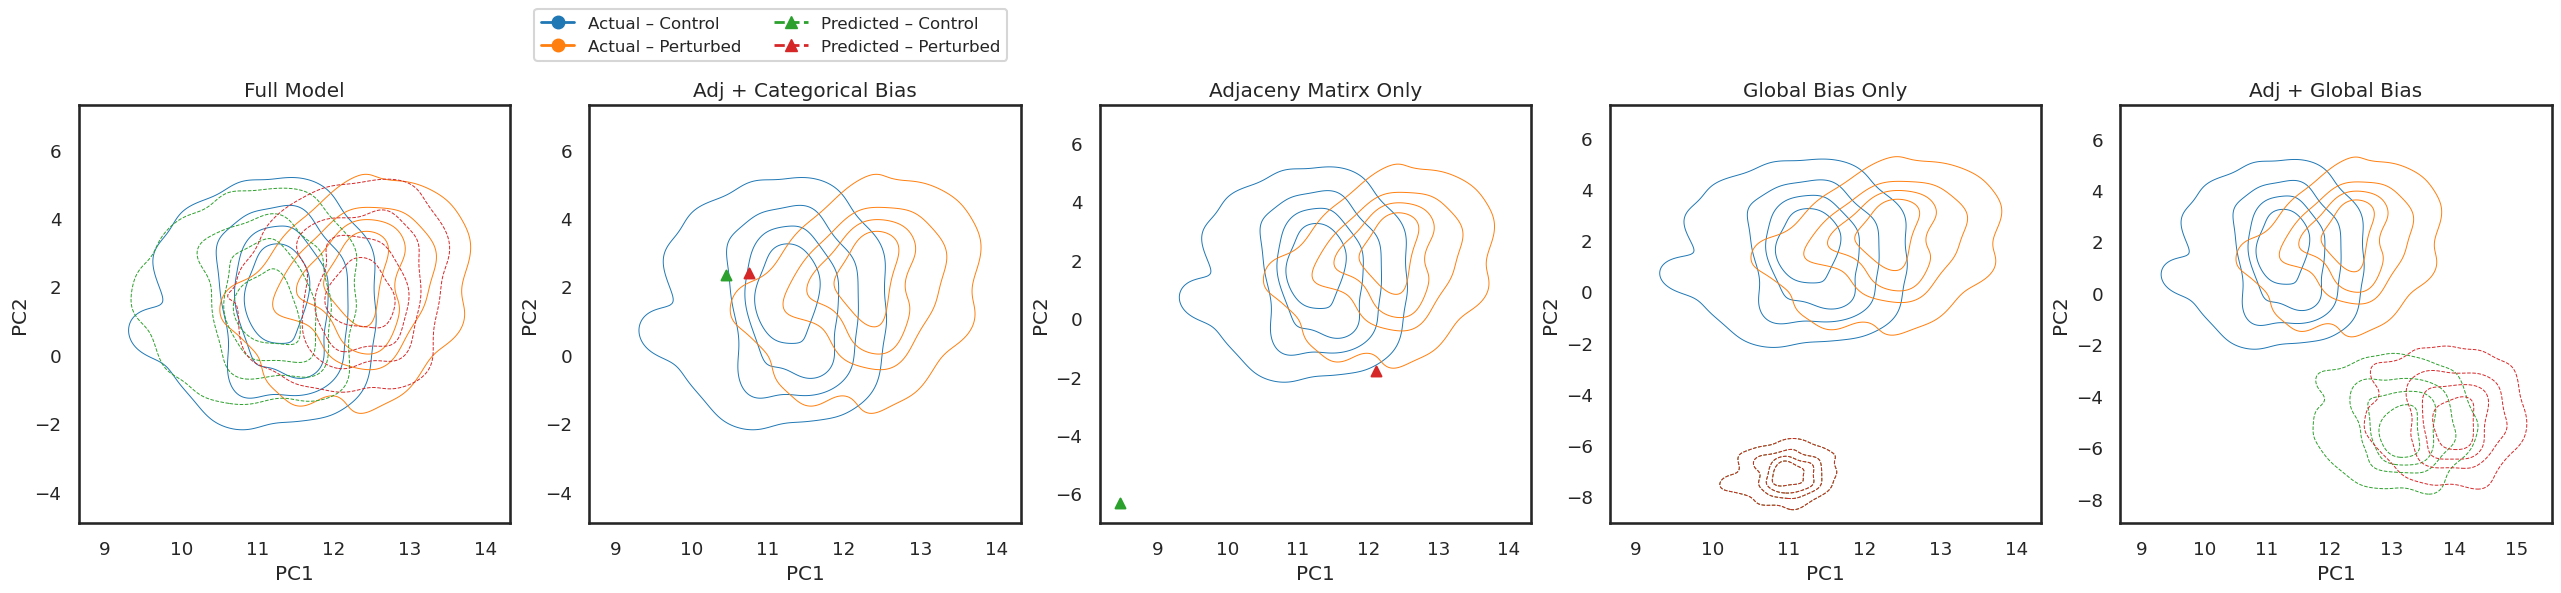

In [118]:
# -------------------- FILTERED COMPONENTS --------------------

remaining_components = {
    'none': 'Full Model',
    'global_bias': 'Adj + Categorical Bias',
    'total_bias': 'Adjaceny Matirx Only',
    'adj^categorical_bias': 'Global Bias Only',
    'categorical_bias': 'Adj + Global Bias',
}

selected_remove_types = list(remaining_components.keys())


# -------------------- CORE FUNCTIONS --------------------

def load_cf_tf_adata(merged_adatas, fold, test_cond, key: str = 'none'):

    key_ = '{}_{}'.format(key, fold)
    tf_adata_merged = merged_adatas[key_].copy()

    ct, pert = test_cond.split('^')
    ctrl_pert = rev_stim[pert]
    ctrl_cond = '^'.join([ct, ctrl_pert])
    cf_mask = tf_adata_merged.obs.condition.isin([test_cond, ctrl_cond])

    tf_adata_test = tf_adata_merged[cf_mask,:].copy()

    assert tf_adata_test.obs[cat_col].nunique() == 1
    assert tf_adata_test.obs[pert_col].nunique() == 2

    actual_mask = (tf_adata_test.obs.batch == 'actual')
    tf_adata_actual = tf_adata_test[actual_mask, :].copy()

    pred_mask = tf_adata_test.obs.batch.isin(['predicted', 'predicted_ctrl'])
    tf_adata_predicted = tf_adata_test[pred_mask, :].copy()

    assert tf_adata_predicted.obs.counterfactual_condition.nunique() == 1
    assert tf_adata_predicted.obs.counterfactual_condition.tolist()[0] == ctrl_cond

    tf_adata_actual = clear_adata(tf_adata_actual)
    tf_adata_predicted = clear_adata(tf_adata_predicted)

    tf_adata_actual.obsm['X_pca'] = pca_mod.transform(tf_adata_actual.X)
    tf_adata_predicted.obsm['X_pca'] = pca_mod.transform(tf_adata_predicted.X)

    return tf_adata_actual, tf_adata_predicted


def all_rows_close(df, rtol=1e-5, atol=1e-8):
    return np.allclose(df.to_numpy(), df.to_numpy()[0], rtol=rtol, atol=atol)


def plot_fold_column(tf_adata_actual, tf_adata_predicted, test_cond,
                     remove_type, ls, ax, min_points_kde=75, is_last_col=False):

    adata_dict = {'Actual': tf_adata_actual, 'Predicted': tf_adata_predicted}

    ct, test_pert = test_cond.split('^')
    ctrl_pert = rev_stim[test_pert]
    perts = [ctrl_pert, test_pert]

    dfs = []
    for adata_type, adata in adata_dict.items():
        df = pd.DataFrame(adata.obsm[f'X_{ls}'])
        df.columns = [f"{ls_label_dict[ls]}{i+1}" for i in range(df.shape[1])]
        df[pert_col] = adata.obs[pert_col].astype(str).values
        df = df[df[pert_col].isin(perts)].copy()
        df["adata_type"] = adata_type
        df["group4"] = df["adata_type"] + "|" + df[pert_col]
        dfs.append(df)

    viz_df_all = pd.concat(dfs, ignore_index=True)

    group_order = [
        f"Actual|{ctrl_pert}", f"Actual|{test_pert}",
        f"Predicted|{ctrl_pert}", f"Predicted|{test_pert}",
    ]

    go_values = [
        "Actual|Control", "Actual|Perturbed",
        "Predicted|Control", "Predicted|Perturbed",
    ]

    viz_df_all["group4"] = pd.Categorical(
        viz_df_all["group4"], categories=group_order, ordered=True
    ).map(dict(zip(group_order, go_values)))

    group_order = go_values

    xcol = f"{ls_label_dict[ls]}1"
    ycol = f"{ls_label_dict[ls]}2"

    palette4 = sns.color_palette(n_colors=4)
    color_map = dict(zip(group_order, palette4))

    # --- KDE ---
    for g in group_order:
        tmp = viz_df_all[viz_df_all["group4"] == g]
        if tmp.shape[0] < min_points_kde:
            continue

        adata_type = g.split("|")[0]

        sns.kdeplot(
            x=tmp[xcol], y=tmp[ycol],
            fill=False, levels=5,
            warn_singular=False,
            ax=ax,
            alpha=1, #if adata_type == "Actual" else 0.5,  # ✅ FIXED
            color=color_map[g],
            linewidths = 0.7, zorder = 0,
            linestyles="-" if adata_type == "Actual" else "--",
        )

    # --- scatter fallback ---
    for g in group_order:
        tmp = viz_df_all[viz_df_all["group4"] == g]
        if tmp.shape[0] >= min_points_kde:
            continue

        adata_type = g.split("|")[0]

        ax.scatter(
            tmp[xcol], tmp[ycol],
            s=50,
            alpha=1, # if adata_type == "Actual" else 0.5,
            marker="o" if adata_type == "Actual" else "^",
            color=color_map[g], 
            zorder = 1
        )

    ax.set_title(remaining_components[remove_type])

    # legend
    handles, labels = [], []
    for g in group_order:
        adata_type, pert = g.split("|")
        handles.append(Line2D(
            [0], [0],
            color=color_map[g],
            lw=2,
            linestyle="-" if adata_type == "Actual" else "--",
            marker="o" if adata_type == "Actual" else "^",
        ))
        labels.append(f"{adata_type} – {pert}")

    ax.legend(handles, labels)
    ax.set_xlabel(f"{ls_label_dict[ls]}1")
    ax.set_ylabel(f"{ls_label_dict[ls]}2")


# -------------------- MAIN PLOT --------------------

def plot_single_condition(
    merged_adatas,
    fold=0,
    test_cond='DC^STIM',
    ls='pca',
    show_fig=True,
    fig_name=None
):
    plt.close('all')

    ncols = len(selected_remove_types)

    fig, ax = plt.subplots(
        1, ncols,
        figsize=(ncols * 5.1, 5.1),
        constrained_layout=True
    )

    if ncols == 1:
        ax = np.array([ax])

    for j, remove_type in enumerate(selected_remove_types):

        tf_adata_actual, tf_adata_predicted = load_cf_tf_adata(
            merged_adatas, fold, test_cond, key=remove_type
        )

        plot_fold_column(
            tf_adata_actual,
            tf_adata_predicted,
            test_cond,
            remove_type,
            ls,
            ax[j],
            is_last_col=(j == ncols - 1)
        )

        if j != 0 and ax[j].get_legend():
            ax[j].legend_.remove()

    # unified legend
    leg = ax[0].get_legend()
    fig.legend(
        leg.legend_handles,
        [t.get_text() for t in leg.get_texts()],
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.3, 1.15)
    )
    ax[0].legend_.remove()

#     fig.suptitle(f"Fold: {fold + 1} | {test_cond}", fontsize=20, y=1.05)

    if fig_name is not None:
        plt.savefig(f"{fig_name}.png", dpi=1200, bbox_inches="tight", transparent=True)
        plt.savefig(f"{fig_name}.svg", bbox_inches="tight")

    if show_fig:
        plt.show()
        
        
plot_single_condition(
    merged_adatas=merged_adatas,
    fold=0,
    test_cond='DC^STIM',
    fig_name=os.path.join(data_path, 'figures', 'DC_STIM_fold0_components')
)

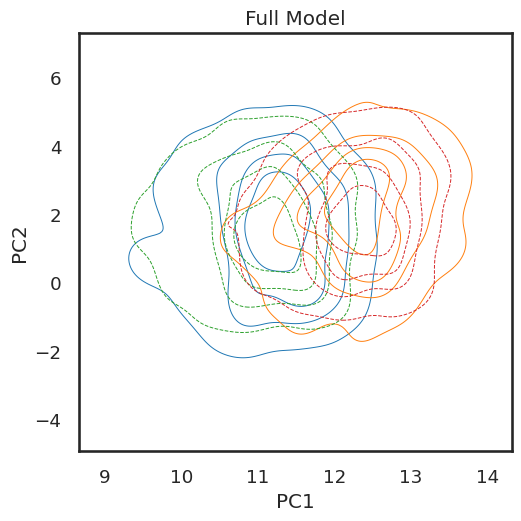

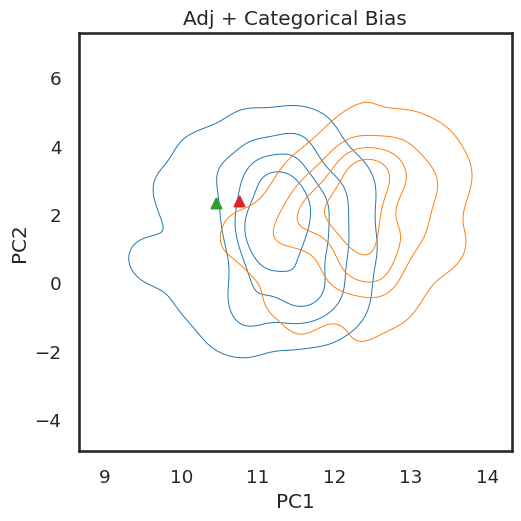

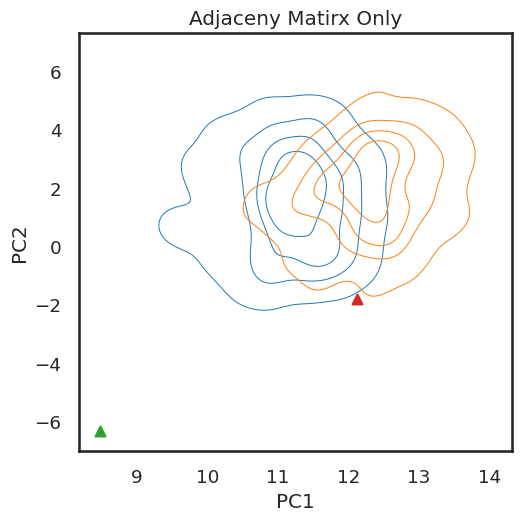

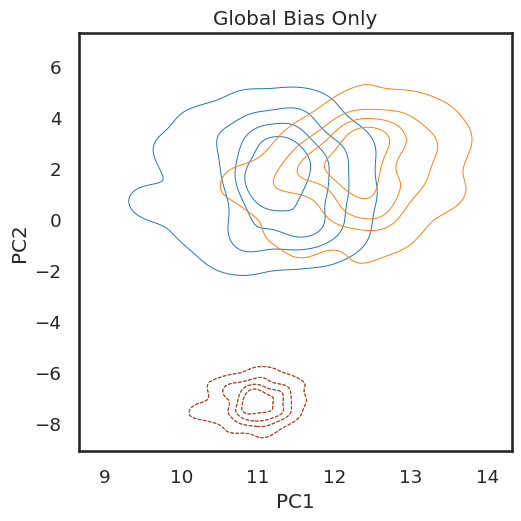

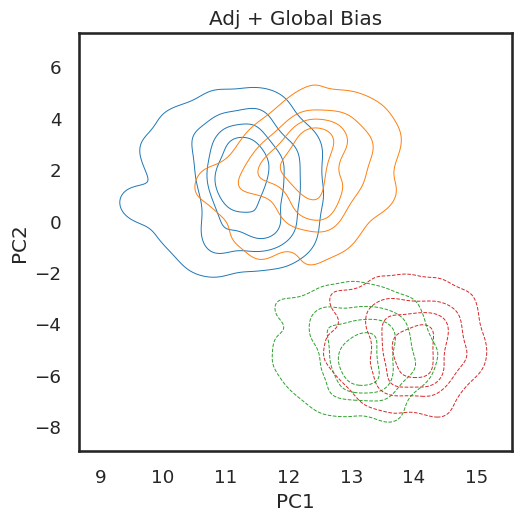

In [120]:
def plot_single_condition_separate_panels(
    merged_adatas,
    fold=0,
    test_cond='DC^STIM',
    ls='pca',
    show_fig=True,
    fig_name=None
):
    plt.close('all')

    for remove_type in selected_remove_types:

        fig, ax = plt.subplots(
            1, 1,
            figsize=(5.1, 5.1),
            constrained_layout=True
        )

        tf_adata_actual, tf_adata_predicted = load_cf_tf_adata(
            merged_adatas, fold, test_cond, key=remove_type
        )

        plot_fold_column(
            tf_adata_actual,
            tf_adata_predicted,
            test_cond,
            remove_type,
            ls,
            ax,
            is_last_col=True
        )

        # ❌ remove legend completely
        if ax.get_legend() is not None:
            ax.legend_.remove()

        # optional: remove title if you want cleaner panels
        ax.set_title(remaining_components[remove_type])

        # --- save ---
        if fig_name is not None:
            base = f"{fig_name}_{remove_type}"

            plt.savefig(
                f"{base}.png",
                dpi=1200,
                bbox_inches="tight",
                transparent=True,
            )

            plt.savefig(
                f"{base}.svg",
                bbox_inches="tight",
            )

        if show_fig:
            plt.show()
        else:
            plt.close(fig)
            
plot_single_condition_separate_panels(
    merged_adatas=merged_adatas,
    fold=0,
    test_cond='DC^STIM',
    fig_name=os.path.join(data_path, 'figures', 'DC_STIM_fold0')
)